# Cosmetics Dataset for Awares Chemicals in Cosmetic Products
> These data reflect information that has been reported to the California Safe Cosmetics Program (CSCP) in the California Department of Public Health (CDPH). The primary purpose of the CSCP is to collect information on hazardous and potentially hazardous ingredients in cosmetic products sold in California and to make this information available to the public.

> For all cosmetic products sold in California, the California Safe Cosmetics Act (“the Act”) requires the manufacturer, packer, and/or distributor named on the product label to provide to the CSCP a list of all cosmetic products that contain any ingredients known or suspected to cause cancer, birth defects, or other developmental or reproductive harm.

> To assist companies with reporting, CDPH has compiled a list of reportable ingredients based on lists and reports available from the authoritative scientific bodies cited in the Act to cause cancer or reproductive harm; it is meant to serve as guidance and is not all-inclusive. Companies with reportable ingredients in their products must submit information to the California Safe Cosmetics Program if the company:

> Has annual aggregate sales of cosmetic products of one million dollars or more, and
Has sold cosmetic products in California on or after January 1, 2007.
The data table consists of: label names of cosmetic/personal care products, company/manufacturer names, product brand names, product categories, Chemical Abstracts Service registry numbers (CAS#) of the reported chemical ingredients, names of reported chemical ingredients, the number of reported chemicals for each product, and dates of reporting, product discontinuation or reformulation if applicable.

> All products containing carcinogens or developmental or reproductive toxicants may not be included due to companies failing to report.

In [42]:
# for data wrangling
import pandas as pd
import numpy as np

#for data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#for pre processing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder

# for evaluation
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

# model
# for reggression algorithms
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor,RandomForestRegressor,BaggingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

#for classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor
from sklearn import model_selection
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

In [43]:
cosmetics = pd.read_csv('chemicals_cosmetics.csv', encoding='latin1')

cosmetics 

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,NaN,07/01/2009,07/01/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,NaN,07/02/2009,07/02/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES ý,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,NaN,07/09/2009,07/09/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES ý,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114630,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65001.0,Rosa Soft,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68059,Titanium dioxide,06/19/2020,06/19/2020,NaN,06/19/2020,06/19/2020,NaN,1
114631,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65002.0,Malva Spirit,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68060,Titanium dioxide,06/19/2020,06/19/2020,NaN,06/19/2020,06/19/2020,NaN,1
114632,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65003.0,Rojo Fashion,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68061,Titanium dioxide,06/19/2020,06/19/2020,NaN,06/19/2020,06/19/2020,NaN,1
114633,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65004.0,Terra Mystic,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68062,Titanium dioxide,06/19/2020,06/19/2020,NaN,06/19/2020,06/19/2020,NaN,1


## Understand the Data

In [44]:
cosmetics.shape

(114635, 22)

In [45]:
print('The features of the Dataset')
# features=len(df.columns)
features_list=[feature for feature in cosmetics.columns]
for feature in features_list:
    print(feature)

The features of the Dataset
CDPHId
ProductName
CSFId
CSF
CompanyId
CompanyName
BrandName
PrimaryCategoryId
PrimaryCategory
SubCategoryId
SubCategory
CasId
CasNumber
ChemicalId
ChemicalName
InitialDateReported
MostRecentDateReported
DiscontinuedDate
ChemicalCreatedAt
ChemicalUpdatedAt
ChemicalDateRemoved
ChemicalCount


Feature Descriptions

> `CDPHId:`	A unique identification number assigned by the California Department of Public Health (CDPH) for each product record. It ensures that each entry in the dataset can be distinctly identified.

> `ProductName:`	The name of the cosmetic or personal care product that contains one or more chemicals (e.g., “Moisturizing Lotion,” “Hair Conditioner”).

> `CSFId:`	The Cosmetic Submission Form (CSF) ID number that tracks the submission of the product’s chemical details to the CDPH database.

> `CSF:`	The formulation name or version used in the CSF record. It represents the specific product formulation that was submitted.

> `CompanyId:`	A unique numeric identifier for the company that manufactures or distributes the product.

> `CompanyName:`	The name of the company responsible for the product (e.g., “Procter & Gamble,” “L’Oréal USA”).

> `BrandName:`	The brand label under which the product is sold (e.g., “Dove,” “Neutrogena,” “Olay”).

> `PrimaryCategoryId:`	A numeric ID used to identify the main category of the product (e.g., Hair Care, Skin Care, Makeup).

> `PrimaryCategory:`	The main classification of the product that describes its overall purpose or type (e.g., “Fragrance,” “Shampoo,” “Body Lotion”).

>`SubCategoryId:`	The numeric ID for a more detailed product type within the main category.

> `SubCategory:`	A specific sub-classification of the product (e.g., “Lipstick,” “Face Cream,” “Conditioner”).

> `CasId:`	The internal ID assigned to the CAS Registry entry.

> `CasNumber:`	The Chemical Abstracts Service (CAS) Registry Number, a globally recognized unique identifier for chemical substances (e.g., “50-00-0” for formaldehyde).

> `ChemicalId:`	The unique numeric ID used in the database for each chemical substance.

> `ChemicalName:`	The name of the chemical ingredient found in the product (e.g., “Formaldehyde,” “Paraben,” “Titanium Dioxide”).

> `InitialDateReported:`	The first date when the product or chemical combination was officially reported to CDPH. It indicates when the chemical first appeared in the record.

> `MostRecentDateReported:`	The latest date when the product or chemical information was last updated or confirmed in the CDPH system.

> `DiscontinuedDate:`	The date when the product was discontinued, if it is no longer manufactured or sold. It helps identify whether the chemical is still in use.

> `ChemicalCreatedAt:`	The timestamp when the chemical record was first added to the database system. It tracks data entry time.

> `ChemicalUpdatedAt:`	The timestamp showing the last update made to the chemical record in the system.

> `ChemicalDateRemoved:`	The date when the chemical was officially removed from the database or product list, often due to discontinuation or regulation.

> `ChemicalCount:`	The target variable in this dataset. It represents the number of cosmetic products that contain a specific chemical. This value shows how commonly a chemical is used across different products and brands.

In [46]:
cosmetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114635 entries, 0 to 114634
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CDPHId                  114635 non-null  int64  
 1   ProductName             114635 non-null  object 
 2   CSFId                   80662 non-null   float64
 3   CSF                     80237 non-null   object 
 4   CompanyId               114635 non-null  int64  
 5   CompanyName             114635 non-null  object 
 6   BrandName               114408 non-null  object 
 7   PrimaryCategoryId       114635 non-null  int64  
 8   PrimaryCategory         114635 non-null  object 
 9   SubCategoryId           114635 non-null  int64  
 10  SubCategory             114635 non-null  object 
 11  CasId                   114635 non-null  int64  
 12  CasNumber               108159 non-null  object 
 13  ChemicalId              114635 non-null  int64  
 14  ChemicalName        

In [47]:
cosmetics.describe()

,CDPHId,CSFId,CompanyId,PrimaryCategoryId,SubCategoryId,CasId,ChemicalId,ChemicalCount
count,114635.000000,80662.000000,114635.000000,114635.000000,114635.000000,114635.000000,114635.000000,114635.000000
mean,20304.858987,32608.658377,450.641532,51.076294,66.819252,674.094107,32837.556959,1.288359
std,12489.052554,19089.443910,409.533093,20.474341,35.822097,149.214101,20439.412299,0.636418
min,2.000000,1.000000,4.000000,1.000000,3.000000,2.000000,0.000000,0.000000
25%,8717.000000,15789.000000,86.000000,44.000000,48.000000,656.000000,13990.000000,1.000000
50%,20895.000000,32541.000000,297.000000,44.000000,52.000000,656.000000,32055.000000,1.000000
75%,31338.500000,48717.750000,798.000000,59.000000,65.000000,656.000000,51578.500000,1.000000
max,41524.000000,65009.000000,1391.000000,111.000000,172.000000,1242.000000,68074.000000,9.000000


In [48]:
cosmetics.describe(include=['O'])

,ProductName,CSF,CompanyName,BrandName,PrimaryCategory,SubCategory,CasNumber,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved
count,114635,80237,114635,114408,114635,114635,108159,114635,114635,114635,12920,114635,114635,2985
unique,33716,34326,606,2713,13,89,125,123,2274,2178,991,2320,2326,524
top,Eyecolor,Black,L'Oreal USA,SEPHORA,Makeup Products (non-permanent),"Lip Color - Lipsticks, Liners, and Pencils",13463-67-7,Titanium dioxide,10/13/2009,12/30/2010,10/02/2016,10/13/2009,10/13/2009,12/14/2009
freq,766,247,5747,3394,75827,16555,93049,93480,2557,18127,1454,2742,2645,159


In [49]:
cosmetics.isnull().sum().sum()

np.int64(288439)

### Cleaning Data

In [50]:
cosmetics['CSFId'].fillna(cosmetics['CSFId'].mode()[0], inplace=True)
cosmetics['CSF'].fillna(cosmetics['CSF'].mode()[0], inplace=True)
cosmetics['BrandName'].fillna(cosmetics['BrandName'].mode()[0], inplace=True)
cosmetics['CasNumber'].fillna(cosmetics['CasNumber'].mode()[0], inplace=True)
cosmetics['DiscontinuedDate'].fillna('Not Discontinued', inplace=True)
cosmetics['ChemicalDateRemoved'].fillna('Not Removed', inplace=True)
cosmetics

C:\Users\USER\AppData\Local\Temp\ipykernel_6160\2363456576.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cosmetics['CSFId'].fillna(cosmetics['CSFId'].mode()[0], inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_6160\2363456576.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,Not Removed,1
1,3,Glover's Medicated Shampoo,54453.0,Black,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,Not Discontinued,07/01/2009,07/01/2009,Not Removed,2
2,3,Glover's Medicated Shampoo,54453.0,Black,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,Not Discontinued,07/02/2009,07/02/2009,Not Removed,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES ý,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,Not Discontinued,07/09/2009,07/09/2009,Not Removed,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES ý,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,Not Removed,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114630,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65001.0,Rosa Soft,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68059,Titanium dioxide,06/19/2020,06/19/2020,Not Discontinued,06/19/2020,06/19/2020,Not Removed,1
114631,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65002.0,Malva Spirit,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68060,Titanium dioxide,06/19/2020,06/19/2020,Not Discontinued,06/19/2020,06/19/2020,Not Removed,1
114632,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65003.0,Rojo Fashion,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68061,Titanium dioxide,06/19/2020,06/19/2020,Not Discontinued,06/19/2020,06/19/2020,Not Removed,1
114633,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65004.0,Terra Mystic,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68062,Titanium dioxide,06/19/2020,06/19/2020,Not Discontinued,06/19/2020,06/19/2020,Not Removed,1


In [51]:
cosmetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114635 entries, 0 to 114634
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CDPHId                  114635 non-null  int64  
 1   ProductName             114635 non-null  object 
 2   CSFId                   114635 non-null  float64
 3   CSF                     114635 non-null  object 
 4   CompanyId               114635 non-null  int64  
 5   CompanyName             114635 non-null  object 
 6   BrandName               114635 non-null  object 
 7   PrimaryCategoryId       114635 non-null  int64  
 8   PrimaryCategory         114635 non-null  object 
 9   SubCategoryId           114635 non-null  int64  
 10  SubCategory             114635 non-null  object 
 11  CasId                   114635 non-null  int64  
 12  CasNumber               114635 non-null  object 
 13  ChemicalId              114635 non-null  int64  
 14  ChemicalName        

In [52]:
cosmetics

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,Not Removed,1
1,3,Glover's Medicated Shampoo,54453.0,Black,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,Not Discontinued,07/01/2009,07/01/2009,Not Removed,2
2,3,Glover's Medicated Shampoo,54453.0,Black,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,Not Discontinued,07/02/2009,07/02/2009,Not Removed,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES ý,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,Not Discontinued,07/09/2009,07/09/2009,Not Removed,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES ý,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,Not Removed,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114630,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65001.0,Rosa Soft,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68059,Titanium dioxide,06/19/2020,06/19/2020,Not Discontinued,06/19/2020,06/19/2020,Not Removed,1
114631,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65002.0,Malva Spirit,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68060,Titanium dioxide,06/19/2020,06/19/2020,Not Discontinued,06/19/2020,06/19/2020,Not Removed,1
114632,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65003.0,Rojo Fashion,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68061,Titanium dioxide,06/19/2020,06/19/2020,Not Discontinued,06/19/2020,06/19/2020,Not Removed,1
114633,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65004.0,Terra Mystic,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68062,Titanium dioxide,06/19/2020,06/19/2020,Not Discontinued,06/19/2020,06/19/2020,Not Removed,1


# Visualization

In [53]:
# categorical_cols=cosmetics.select_dtypes(include=['object','category']).columns.tolist()
# for col in categorical_cols[1:]:
#     plt.figure(figsize=(6,6))
#     sns.countplot(data=cosmetics,x=col,hue=col)
#     plt.title(f"count plot for {col}")
#     plt.xticks(rotation=45)
#     plt.show()

In [54]:
cosmetics.value_counts('BrandName')

BrandName
SEPHORA              3621
NYX                  3227
bareMinerals         3158
Charlotte Tilbury    2453
Revlon               2335
                     ... 
laneige                 1
08 Nude Elegance        1
07 Shimmer Shell        1
04 Heavens Nude         1
(re)Fresh               1
Name: count, Length: 2713, dtype: int64

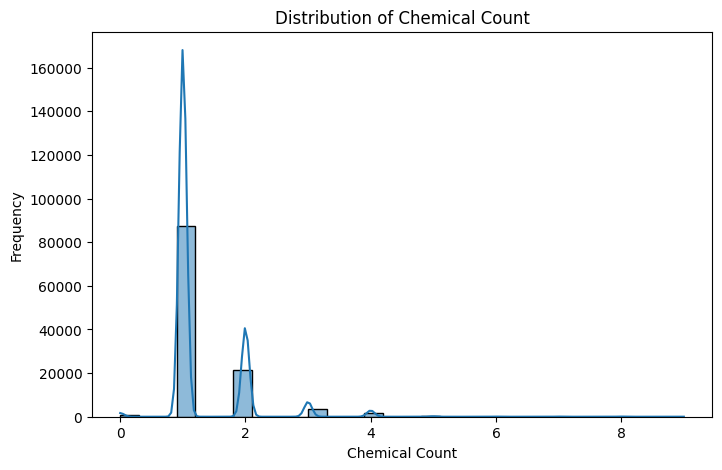

In [55]:
# Distribution of target 'ChemicalCount
plt.figure(figsize=(8,5))
sns.histplot(cosmetics['ChemicalCount'], bins=30, kde=True)
plt.title('Distribution of Chemical Count')
plt.xlabel('Chemical Count')
plt.ylabel('Frequency')
plt.show()


In [56]:
# Top 10 most common chemicals used in cosmetics
top_chemicals = cosmetics.groupby('ChemicalName')['ChemicalCount'].sum().sort_values(ascending=False).head(10)
top_chemicals

ChemicalName
Titanium dioxide                                                                                       108630
Silica, crystalline (airborne particles of respirable size)                                              6045
Mica                                                                                                     4656
Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.      3772
Talc                                                                                                     3585
Butylated hydroxyanisole                                                                                 3402
Carbon black                                                                                             3308
Retinyl palmitate                                                                                        2241
Vitamin A palmitate                                                                                      14

In [57]:
cosmetics.value_counts('ChemicalName')

ChemicalName
Titanium dioxide                                                                                       93480
Silica, crystalline (airborne particles of respirable size)                                             2817
Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.     2154
Mica                                                                                                    1919
Butylated hydroxyanisole                                                                                1888
                                                                                                       ...  
N-Nitrosodiethanolamine                                                                                    1
Sodium Bromate                                                                                             1
Spironolactone                                                                                             1
Retino

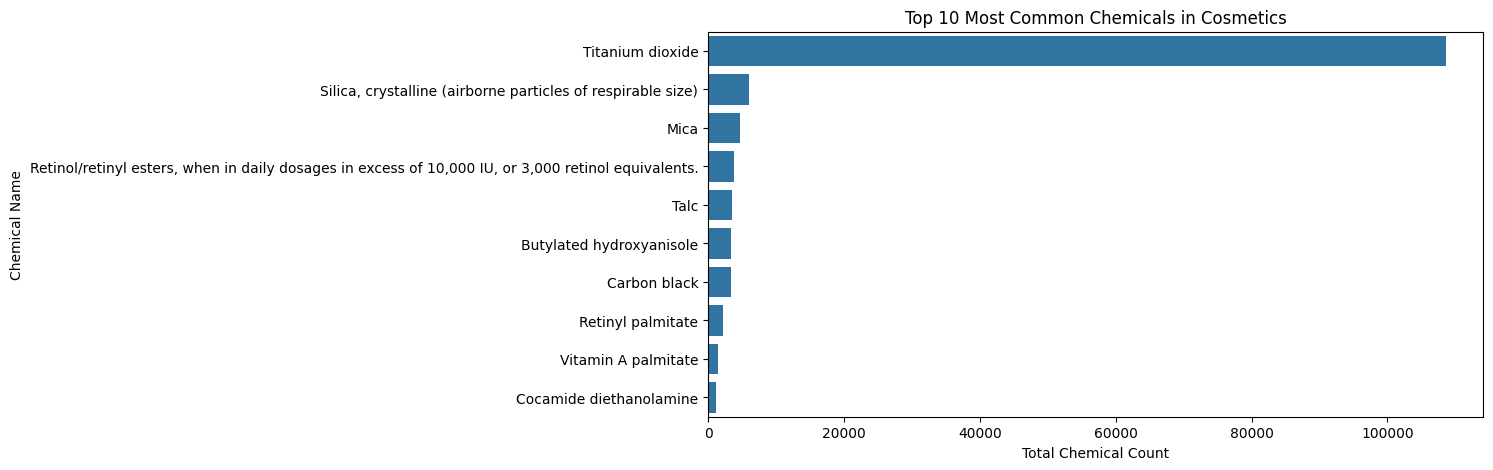

In [58]:

plt.figure(figsize=(10,5))
sns.barplot(x=top_chemicals.values, y=top_chemicals.index)
plt.title('Top 10 Most Common Chemicals in Cosmetics')
plt.xlabel('Total Chemical Count')
plt.ylabel('Chemical Name')
plt.show()


> Titanium Dioxide is the common used chemical in cosmetics than others

In [59]:
# Company-wise average chemical count
top_companies = cosmetics.groupby('CompanyName')['ChemicalCount'].mean().sort_values(ascending=False).head(10)
top_companies

CompanyName
Regis Corporation                   4.803571
Cosmopharm Ltd.                     4.461538
Vitamin World, Inc.                 3.303030
Chrome Hearts LLC                   3.227273
Good 'N Natural                     3.000000
Puritan's Pride                     2.962963
DERMAQUEST, INC.                    2.600000
Palladio Beauty Group               2.583173
Exclusive Fragrances & Cosmetics    2.515625
Charlotte Tilbury Beauty Ltd        2.424549
Name: ChemicalCount, dtype: float64

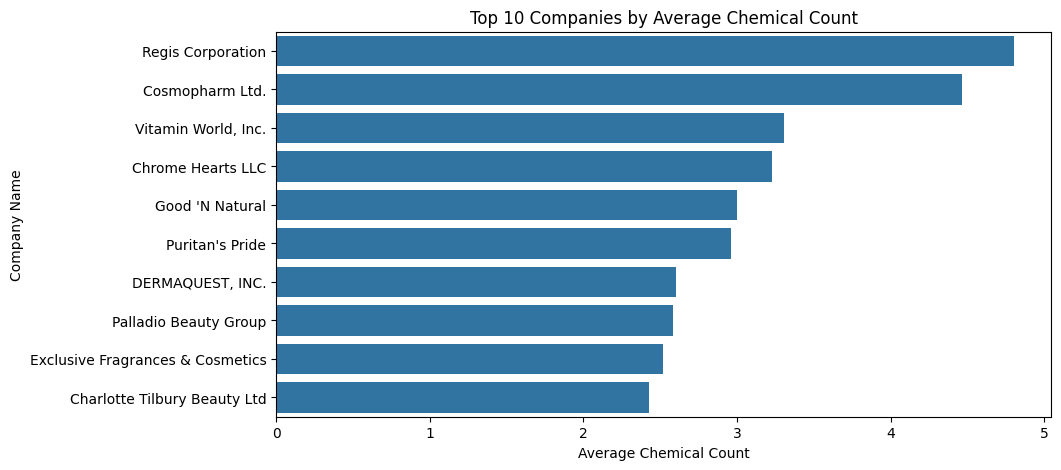

In [60]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_companies.values, y=top_companies.index)
plt.title('Top 10 Companies by Average Chemical Count')
plt.xlabel('Average Chemical Count')
plt.ylabel('Company Name')
plt.show()

> A company called ' Regis Corporation ' is using more chemical in products

In [61]:
category_vs_chemical = cosmetics.groupby('PrimaryCategory')['ChemicalCount'].mean().sort_values(ascending=False)
category_vs_chemical

PrimaryCategory
Tattoos and Permanent Makeup         1.480704
Hair Care Products (non-coloring)    1.416049
Makeup Products (non-permanent)      1.319794
Nail Products                        1.301492
Shaving Products                     1.220721
Skin Care Products                   1.202135
Sun-Related Products                 1.171290
Bath Products                        1.069821
Fragrances                           1.056575
Hair Coloring Products               1.029112
Oral Hygiene Products                1.015238
Personal Care Products               1.002614
Baby Products                        0.979592
Name: ChemicalCount, dtype: float64

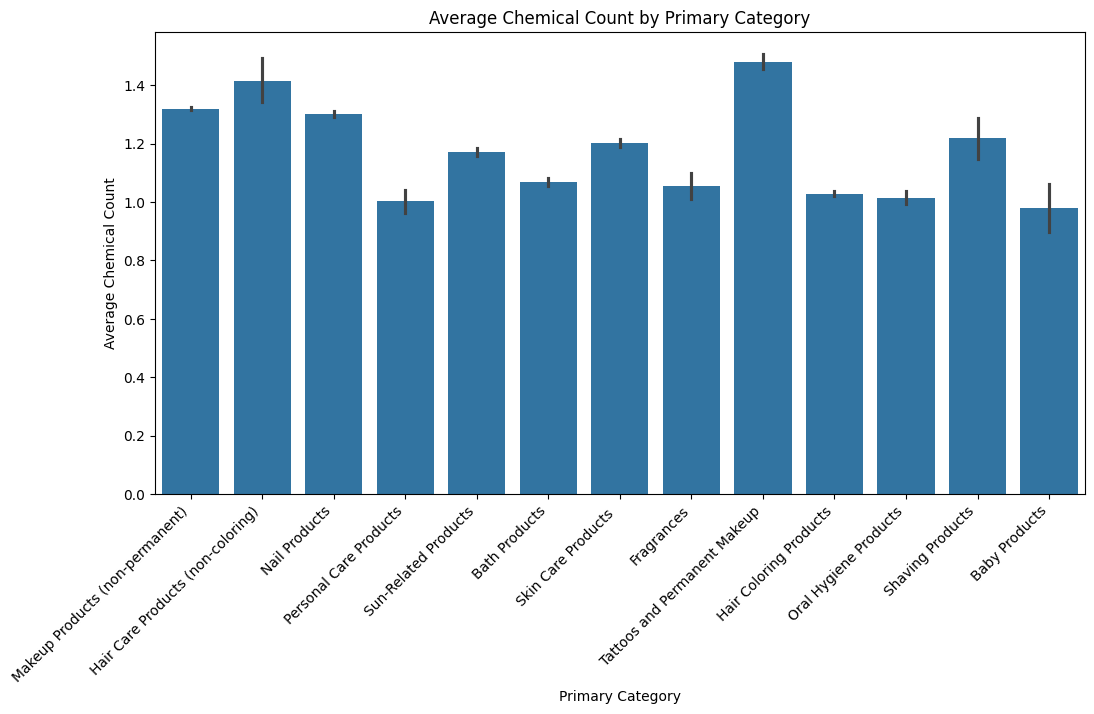

In [62]:
# Primary Category vs Average Chemical Count
plt.figure(figsize=(12,6))
sns.barplot(x='PrimaryCategory', y='ChemicalCount', data=cosmetics, estimator='mean')
plt.xticks(rotation=45, ha='right')
plt.title('Average Chemical Count by Primary Category')
plt.xlabel('Primary Category')
plt.ylabel('Average Chemical Count')
plt.show()


> Tattoos and Permanent Makeup using more chemicals 

> Baby products uses very less chemicals

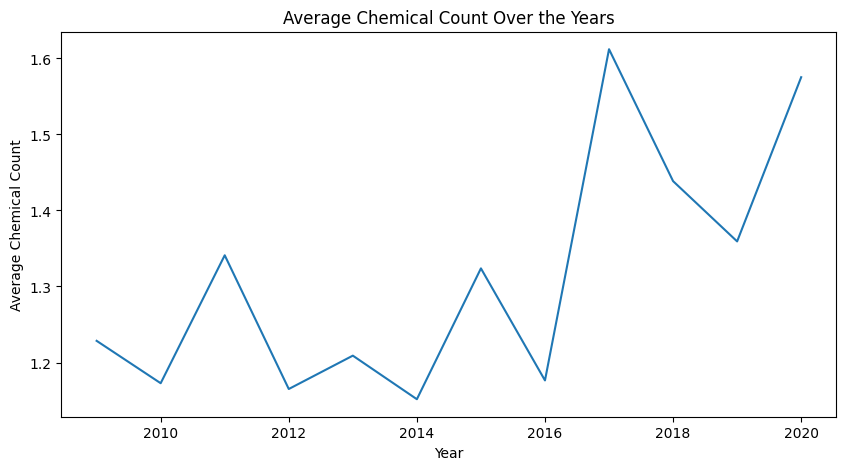

In [63]:
# Relationship between InitialDateReported and ChemicalCount
cosmetics['InitialDateReported'] = pd.to_datetime(cosmetics['InitialDateReported'], errors='coerce')
cosmetics['Year'] = cosmetics['InitialDateReported'].dt.year

yearly = cosmetics.groupby('Year')['ChemicalCount'].mean().dropna()

plt.figure(figsize=(10,5))
sns.lineplot(x=yearly.index, y=yearly.values)
plt.title('Average Chemical Count Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Chemical Count')
plt.show()


> Chemical usage in products increased over year in 2016-2018

In [64]:
cosmetics.columns

Index(['CDPHId', 'ProductName', 'CSFId', 'CSF', 'CompanyId', 'CompanyName',
       'BrandName', 'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId',
       'SubCategory', 'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName',
       'InitialDateReported', 'MostRecentDateReported', 'DiscontinuedDate',
       'ChemicalCreatedAt', 'ChemicalUpdatedAt', 'ChemicalDateRemoved',
       'ChemicalCount', 'Year'],
      dtype='object')

In [65]:
# categorical_cols=cosmetics.select_dtypes(include=['object','category']).columns.tolist()
# for col in categorical_cols[1:]:
#     plt.figure(figsize=(8,4))
#     sns.countplot(data=cosmetics,x=col,hue='PrimaryCategory',palette='Greys')
#     plt.title(f"count plot for {col}")
#     plt.show()

## Feature Engineering

In [66]:
cosmetics.value_counts('DiscontinuedDate')

DiscontinuedDate
Not Discontinued    101715
10/02/2016            1454
03/31/2017             423
01/01/2014             389
07/10/2013             355
                     ...  
08/05/2015               1
08/05/2013               1
08/05/2011               1
08/05/2010               1
12/26/2007               1
Name: count, Length: 992, dtype: int64

In [67]:
cosmetics.value_counts('ChemicalDateRemoved')

ChemicalDateRemoved
Not Removed    111650
12/14/2009        159
12/05/2103        114
10/13/2009        111
10/06/2009        110
                ...  
12/23/2013          1
12/24/2010          1
01/01/2015          1
12/31/2018          1
01/01/2000          1
Name: count, Length: 525, dtype: int64

In [68]:
#Convert both columns to datetime
cosmetics['MostRecentDateReported'] = pd.to_datetime(cosmetics['MostRecentDateReported'], errors='coerce')
cosmetics['InitialDateReported'] = pd.to_datetime(cosmetics['InitialDateReported'], errors='coerce')


In [69]:
#Subtract the columns
cosmetics['ProductActiveDays'] = (cosmetics['MostRecentDateReported'] - cosmetics['InitialDateReported']).dt.days


In [70]:
# Convert to binary flag
cosmetics['IsDiscontinued'] = cosmetics['DiscontinuedDate'].apply(lambda x: 0 if x == 'Not Discontinued' else 1)

# Drop the original column
cosmetics.drop('DiscontinuedDate', axis=1, inplace=True)


In [71]:
cosmetics.isna().sum()

CDPHId                    0
ProductName               0
CSFId                     0
CSF                       0
CompanyId                 0
CompanyName               0
BrandName                 0
PrimaryCategoryId         0
PrimaryCategory           0
SubCategoryId             0
SubCategory               0
CasId                     0
CasNumber                 0
ChemicalId                0
ChemicalName              0
InitialDateReported       0
MostRecentDateReported    0
ChemicalCreatedAt         0
ChemicalUpdatedAt         0
ChemicalDateRemoved       0
ChemicalCount             0
Year                      0
ProductActiveDays         0
IsDiscontinued            0
dtype: int64

In [72]:
cosmetics.value_counts('MostRecentDateReported')
cosmetics

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,ChemicalName,InitialDateReported,MostRecentDateReported,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Year,ProductActiveDays,IsDiscontinued
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,Titanium dioxide,2009-06-17,2013-08-28,07/09/2009,07/09/2009,Not Removed,1,2009,1533,1
1,3,Glover's Medicated Shampoo,54453.0,Black,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,Distillates (coal tar),2009-07-01,2009-07-01,07/01/2009,07/01/2009,Not Removed,2,2009,0,0
2,3,Glover's Medicated Shampoo,54453.0,Black,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,Estragole,2009-07-01,2009-07-01,07/02/2009,07/02/2009,Not Removed,2,2009,0,0
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES ý,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,Titanium dioxide,2009-07-09,2013-08-28,07/09/2009,07/09/2009,Not Removed,1,2009,1511,0
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES ý,54453.0,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,Titanium dioxide,2009-07-09,2013-08-28,07/09/2009,07/09/2009,Not Removed,1,2009,1511,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114630,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65001.0,Rosa Soft,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,Titanium dioxide,2020-06-19,2020-06-19,06/19/2020,06/19/2020,Not Removed,1,2020,0,0
114631,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65002.0,Malva Spirit,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,Titanium dioxide,2020-06-19,2020-06-19,06/19/2020,06/19/2020,Not Removed,1,2020,0,0
114632,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65003.0,Rojo Fashion,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,Titanium dioxide,2020-06-19,2020-06-19,06/19/2020,06/19/2020,Not Removed,1,2020,0,0
114633,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65004.0,Terra Mystic,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,Titanium dioxide,2020-06-19,2020-06-19,06/19/2020,06/19/2020,Not Removed,1,2020,0,0


In [73]:
company_diversity = cosmetics.groupby('CompanyName')['ChemicalCount'].mean()
company_diversity

CompanyName
2355644 Ontario Inc.                      1.000000
A. P. Deauville, LLC                      1.000000
ACQUA DI PARMA                            1.000000
AFFLINK                                   0.875000
AG PROFESSIONAL HAIR CARE PRODUCTS LTD    1.000000
                                            ...   
laboratoire Sintyl SA                     1.000000
purminerals                               1.813665
rolland srl                               1.000000
salerm cosmýtica profesional,Inc.         1.000000
theBalm                                   1.605042
Name: ChemicalCount, Length: 606, dtype: float64

In [74]:
# Company-level diversity
company_diversity = cosmetics.groupby('CompanyName')['ChemicalCount'].mean()
cosmetics['CompanyChemicalDiversity'] = cosmetics['CompanyName'].map(company_diversity)

# Brand-level diversity (optional)
brand_diversity = cosmetics.groupby('BrandName')['ChemicalCount'].mean()
cosmetics['BrandChemicalDiversity'] = cosmetics['BrandName'].map(brand_diversity)


In [75]:
top_products = cosmetics[['ProductName', 'ChemicalCount']].sort_values(by='ChemicalCount', ascending=False).head(10)
print(top_products)


                ProductName  ChemicalCount
60826  Moisturizing Shampoo              9
60820  Moisturizing Shampoo              9
60823  Moisturizing Shampoo              9
60819  Moisturizing Shampoo              9
60822  Moisturizing Shampoo              9
60821  Moisturizing Shampoo              9
60827  Moisturizing Shampoo              9
60824  Moisturizing Shampoo              9
60825  Moisturizing Shampoo              9
15660   Hydrate Conditioner              8


In [76]:
top_companies = cosmetics.groupby('CompanyName')['ChemicalCount'].mean().sort_values(ascending=False).head(10)
print(top_companies)


CompanyName
Regis Corporation                   4.803571
Cosmopharm Ltd.                     4.461538
Vitamin World, Inc.                 3.303030
Chrome Hearts LLC                   3.227273
Good 'N Natural                     3.000000
Puritan's Pride                     2.962963
DERMAQUEST, INC.                    2.600000
Palladio Beauty Group               2.583173
Exclusive Fragrances & Cosmetics    2.515625
Charlotte Tilbury Beauty Ltd        2.424549
Name: ChemicalCount, dtype: float64


In [77]:
top_brands = cosmetics.groupby('BrandName')['ChemicalCount'].mean().sort_values(ascending=False).head(10)
print(top_brands)

BrandName
Mastercuts                 6.363636
Regis Design Line          5.867347
Careline                   4.461538
Dermaminerals              4.000000
PALLADIO                   4.000000
Dermaquest Skin Therapy    4.000000
Costcutters                4.000000
Zoeva                      4.000000
Perfectly Pure             3.600000
Vitamin World              3.375000
Name: ChemicalCount, dtype: float64


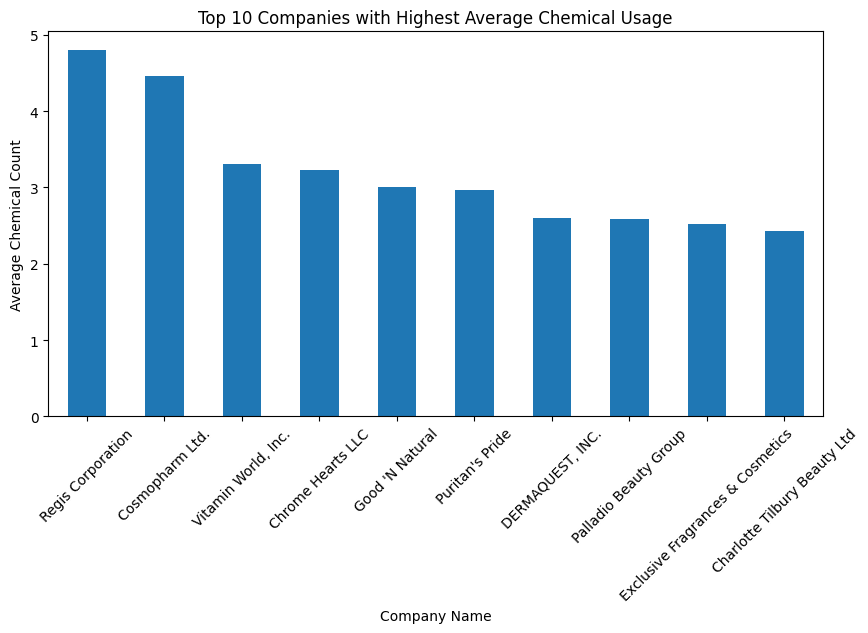

In [78]:
import matplotlib.pyplot as plt

top_companies.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Companies with Highest Average Chemical Usage')
plt.ylabel('Average Chemical Count')
plt.xlabel('Company Name')
plt.xticks(rotation=45)
plt.show()


In [79]:
# Identify “High” vs “Low” Usage Levels
threshold = cosmetics['ChemicalCount'].median()

cosmetics['ChemicalUsageLevel'] = cosmetics['ChemicalCount'].apply(
    lambda x: 'High' if x > threshold else 'Low'
)


In [80]:
# Count products by Brand and Usage Level
brand_usage = cosmetics.groupby(['BrandName', 'ChemicalUsageLevel']).size().unstack(fill_value=0)


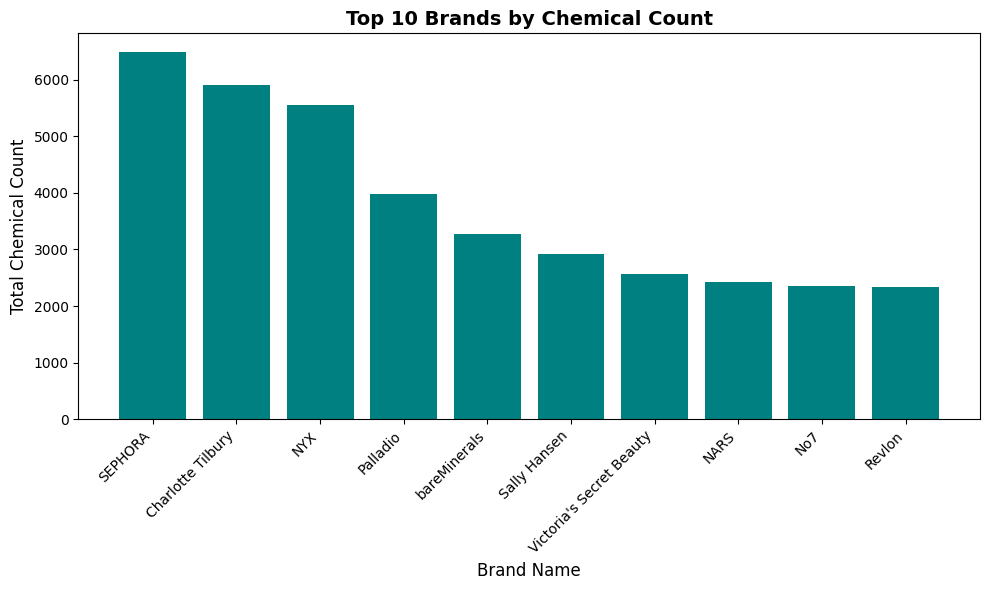

In [86]:
brand_counts = (
    cosmetics.groupby('BrandName')['ChemicalCount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(10,6))

# Plot
plt.bar(brand_counts.index, brand_counts.values, color='teal')

# Add titles and labels
plt.title('Top 10 Brands by Chemical Count', fontsize=14, fontweight='bold')
plt.xlabel('Brand Name', fontsize=12)
plt.ylabel('Total Chemical Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
cosmetics.columns

Index(['CDPHId', 'ProductName', 'CSFId', 'CSF', 'CompanyId', 'CompanyName',
       'BrandName', 'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId',
       'SubCategory', 'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName',
       'InitialDateReported', 'MostRecentDateReported', 'ChemicalCreatedAt',
       'ChemicalUpdatedAt', 'ChemicalDateRemoved', 'ChemicalCount', 'Year',
       'ProductActiveDays', 'IsDiscontinued', 'CompanyChemicalDiversity',
       'BrandChemicalDiversity', 'ChemicalUsageLevel'],
      dtype='object')

In [ ]:
cosmetics.drop('CDPHId',axis=1,inplace=True)

In [ ]:
cosmetics.drop('CSFId',axis=1,inplace=True)

In [ ]:
# Check skewness for main numeric features
# numeric_features = ['ChemicalCount', 'ProductActiveDays', 'CompanyChemicalDiversity']
# cosmetics[numeric_features].skew()


In [ ]:
# import numpy as np

# cosmetics['ChemicalCount_log'] = np.log1p(cosmetics['ChemicalCount'])
# cosmetics['ProductActiveDays_log'] = np.log1p(cosmetics['ProductActiveDays'])
# cosmetics['CompanyChemicalDiversity_log'] = np.log1p(cosmetics['CompanyChemicalDiversity'])

In [ ]:
cosmetics.head(5)

,ProductName,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,SubCategory,CasId,...,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Year,ProductActiveDays,IsDiscontinued,CompanyChemicalDiversity,BrandChemicalDiversity,ChemicalUsageLevel
0,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,"Lip Color - Lipsticks, Liners, and Pencils",656,...,07/09/2009,07/09/2009,Not Removed,1,2009,1533,1,1.007874,1.007890,Low
1,Glover's Medicated Shampoo,Black,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,Hair Shampoos (making a cosmetic claim),889,...,07/01/2009,07/01/2009,Not Removed,2,2009,0,0,0.975610,1.666667,High
2,Glover's Medicated Shampoo,Black,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,Hair Shampoos (making a cosmetic claim),293,...,07/02/2009,07/02/2009,Not Removed,2,2009,0,0,0.975610,1.666667,High
3,PRECISION GLIMMER EYE LINER-ALL SHADES ý,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,Eyeliner/Eyebrow Pencils,656,...,07/09/2009,07/09/2009,Not Removed,1,2009,1511,0,1.007874,1.007890,Low
4,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES ý,Black,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,Lip Gloss/Shine,656,...,07/09/2009,07/09/2009,Not Removed,1,2009,1511,1,1.007874,1.007890,Low


# Encoding


### Ordinal encoding

In [ ]:
cosmetics['ChemicalUsageLevel'] = cosmetics['ChemicalUsageLevel'].map({'Low': 0, 'High': 1})


### Nominal Encoding

In [ ]:
categorical_columns=cosmetics.select_dtypes(include=['object','category']).columns
print('Categorical Columns:', categorical_columns)

Categorical Columns: Index(['ProductName', 'CSF', 'CompanyName', 'BrandName', 'PrimaryCategory',
       'SubCategory', 'CasNumber', 'ChemicalName', 'ChemicalCreatedAt',
       'ChemicalUpdatedAt', 'ChemicalDateRemoved'],
      dtype='object')


In [ ]:
le=LabelEncoder()
for cols in cosmetics.select_dtypes('object').columns:
    cosmetics[cols]=le.fit_transform(cosmetics[cols])

In [ ]:
cosmetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114635 entries, 0 to 114634
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   ProductName               114635 non-null  int64         
 1   CSF                       114635 non-null  int64         
 2   CompanyId                 114635 non-null  int64         
 3   CompanyName               114635 non-null  int64         
 4   BrandName                 114635 non-null  int64         
 5   PrimaryCategoryId         114635 non-null  int64         
 6   PrimaryCategory           114635 non-null  int64         
 7   SubCategoryId             114635 non-null  int64         
 8   SubCategory               114635 non-null  int64         
 9   CasId                     114635 non-null  int64         
 10  CasNumber                 114635 non-null  int64         
 11  ChemicalId                114635 non-null  int64         
 12  Ch

# Data Transformation

## Skewed Data

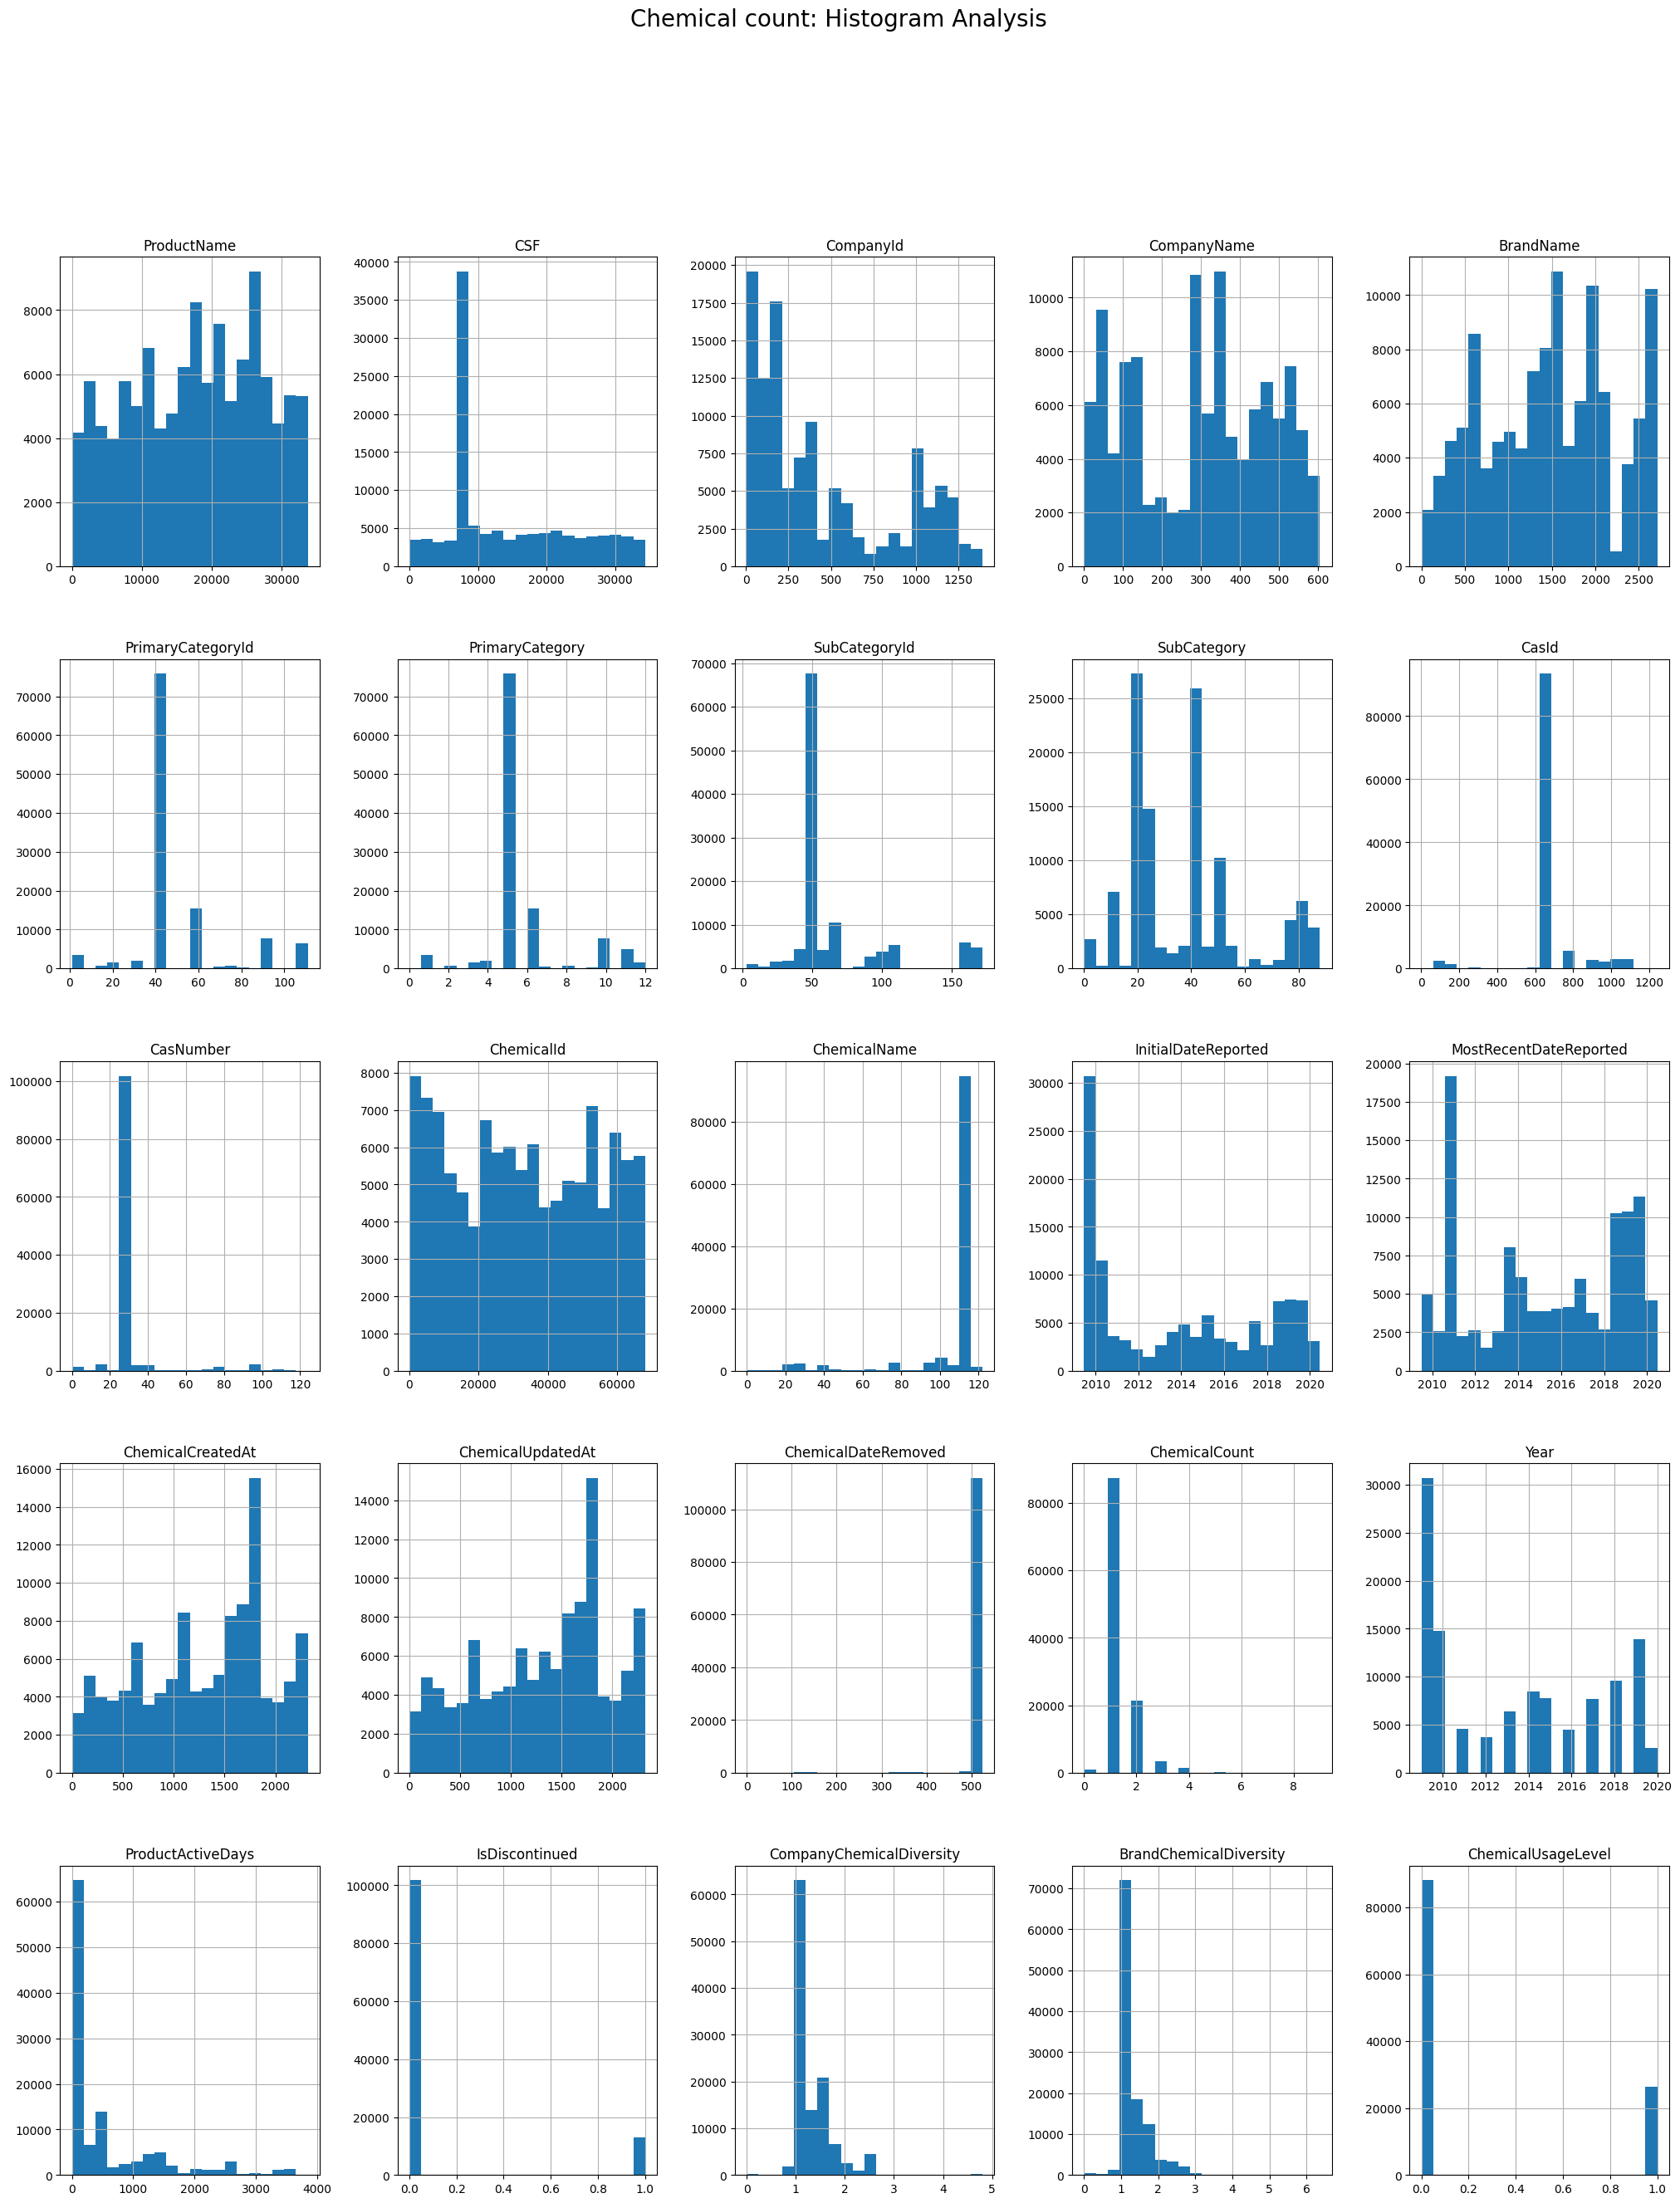

In [ ]:
cosmetics.hist(bins=20,figsize=(25,30))
plt.suptitle('Chemical count: Histogram Analysis', fontsize=20)
plt.show()

In [ ]:
# Drop raw datetime columns
date_cols = [
    'InitialDateReported', 'MostRecentDateReported','ChemicalCreatedAt',
    'ChemicalUpdatedAt', 'ChemicalDateRemoved'
]
cosmetics.drop(date_cols, axis=1, inplace=True)


In [ ]:
# calculate skewness for each column
skewness=cosmetics.skew()
# sort the skewness values in ascending order
sorted_skewness=skewness.sort_values(ascending=True)
# Display the sorted skewness values
print(sorted_skewness)

ChemicalName               -3.199758
CasId                      -0.653333
ProductName                -0.128206
CompanyName                -0.082100
BrandName                  -0.050061
ChemicalId                  0.047893
Year                        0.255449
CSF                         0.628402
CompanyId                   0.774534
SubCategory                 0.838023
PrimaryCategoryId           1.171648
ChemicalUsageLevel          1.275427
PrimaryCategory             1.293910
SubCategoryId               1.820317
ProductActiveDays           1.869146
CompanyChemicalDiversity    2.260865
IsDiscontinued              2.449460
BrandChemicalDiversity      2.585714
ChemicalCount               2.808473
CasNumber                   4.000601
dtype: float64


In [ ]:
# create copy of the original data for comparison
cosmetics_copy=cosmetics.copy()

In [ ]:
cols_to_transform=['PrimaryCategoryId', 'ChemicalUsageLevel', 'PrimaryCategory','SubCategoryId', 'ProductActiveDays', 'CompanyChemicalDiversity', 'IsDiscontinued', 'BrandChemicalDiversity', 'ChemicalCount', 'CasNumber']
for col in cols_to_transform:
    cosmetics[col + '_log'] = np.log1p(cosmetics[col]) 

In [ ]:
cosmetics[['ProductActiveDays_log', 'ChemicalUsageLevel_log','ProductActiveDays_log', 'CompanyChemicalDiversity_log', 'BrandChemicalDiversity_log', 'ChemicalCount_log']].skew()


ProductActiveDays_log           0.126943
ChemicalUsageLevel_log          1.275427
ProductActiveDays_log           0.126943
CompanyChemicalDiversity_log    1.233962
BrandChemicalDiversity_log      1.215816
ChemicalCount_log               1.408615
dtype: float64

In [ ]:
cosmetics.drop(columns=['ChemicalUsageLevel_log'], inplace=True, errors='ignore')


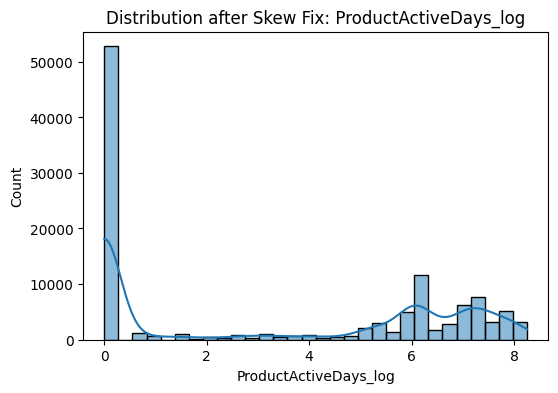

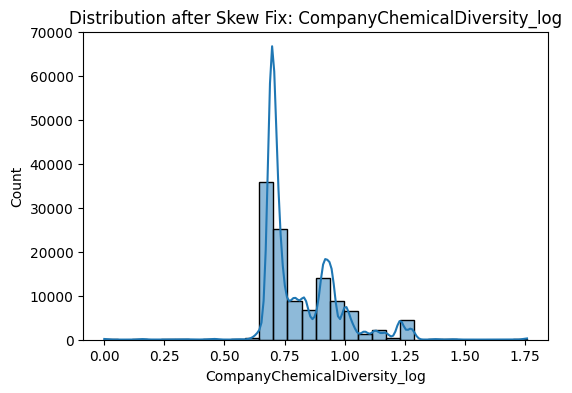

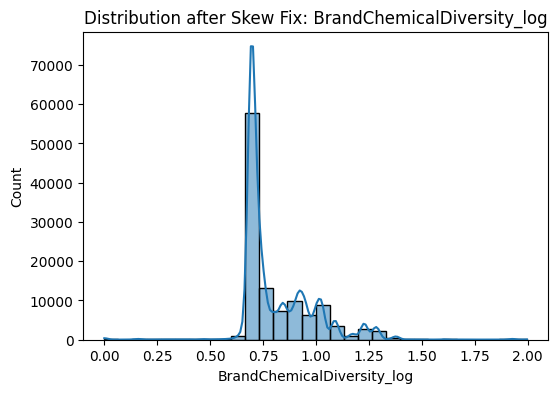

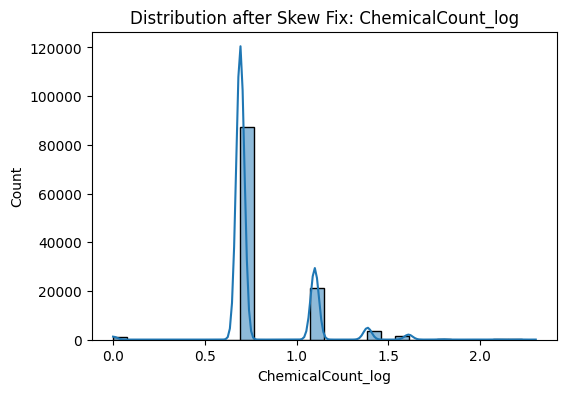

In [ ]:
cols_to_plot = [
    'ProductActiveDays_log',
    'CompanyChemicalDiversity_log',
    'BrandChemicalDiversity_log',
    'ChemicalCount_log'
]

for col in cols_to_plot:
    plt.figure(figsize=(6,4))
    sns.histplot(cosmetics[col], bins=30, kde=True)
    plt.title(f'Distribution after Skew Fix: {col}')
    plt.show()


## Removing Unwanted Features

### Based on correlation

<Axes: >

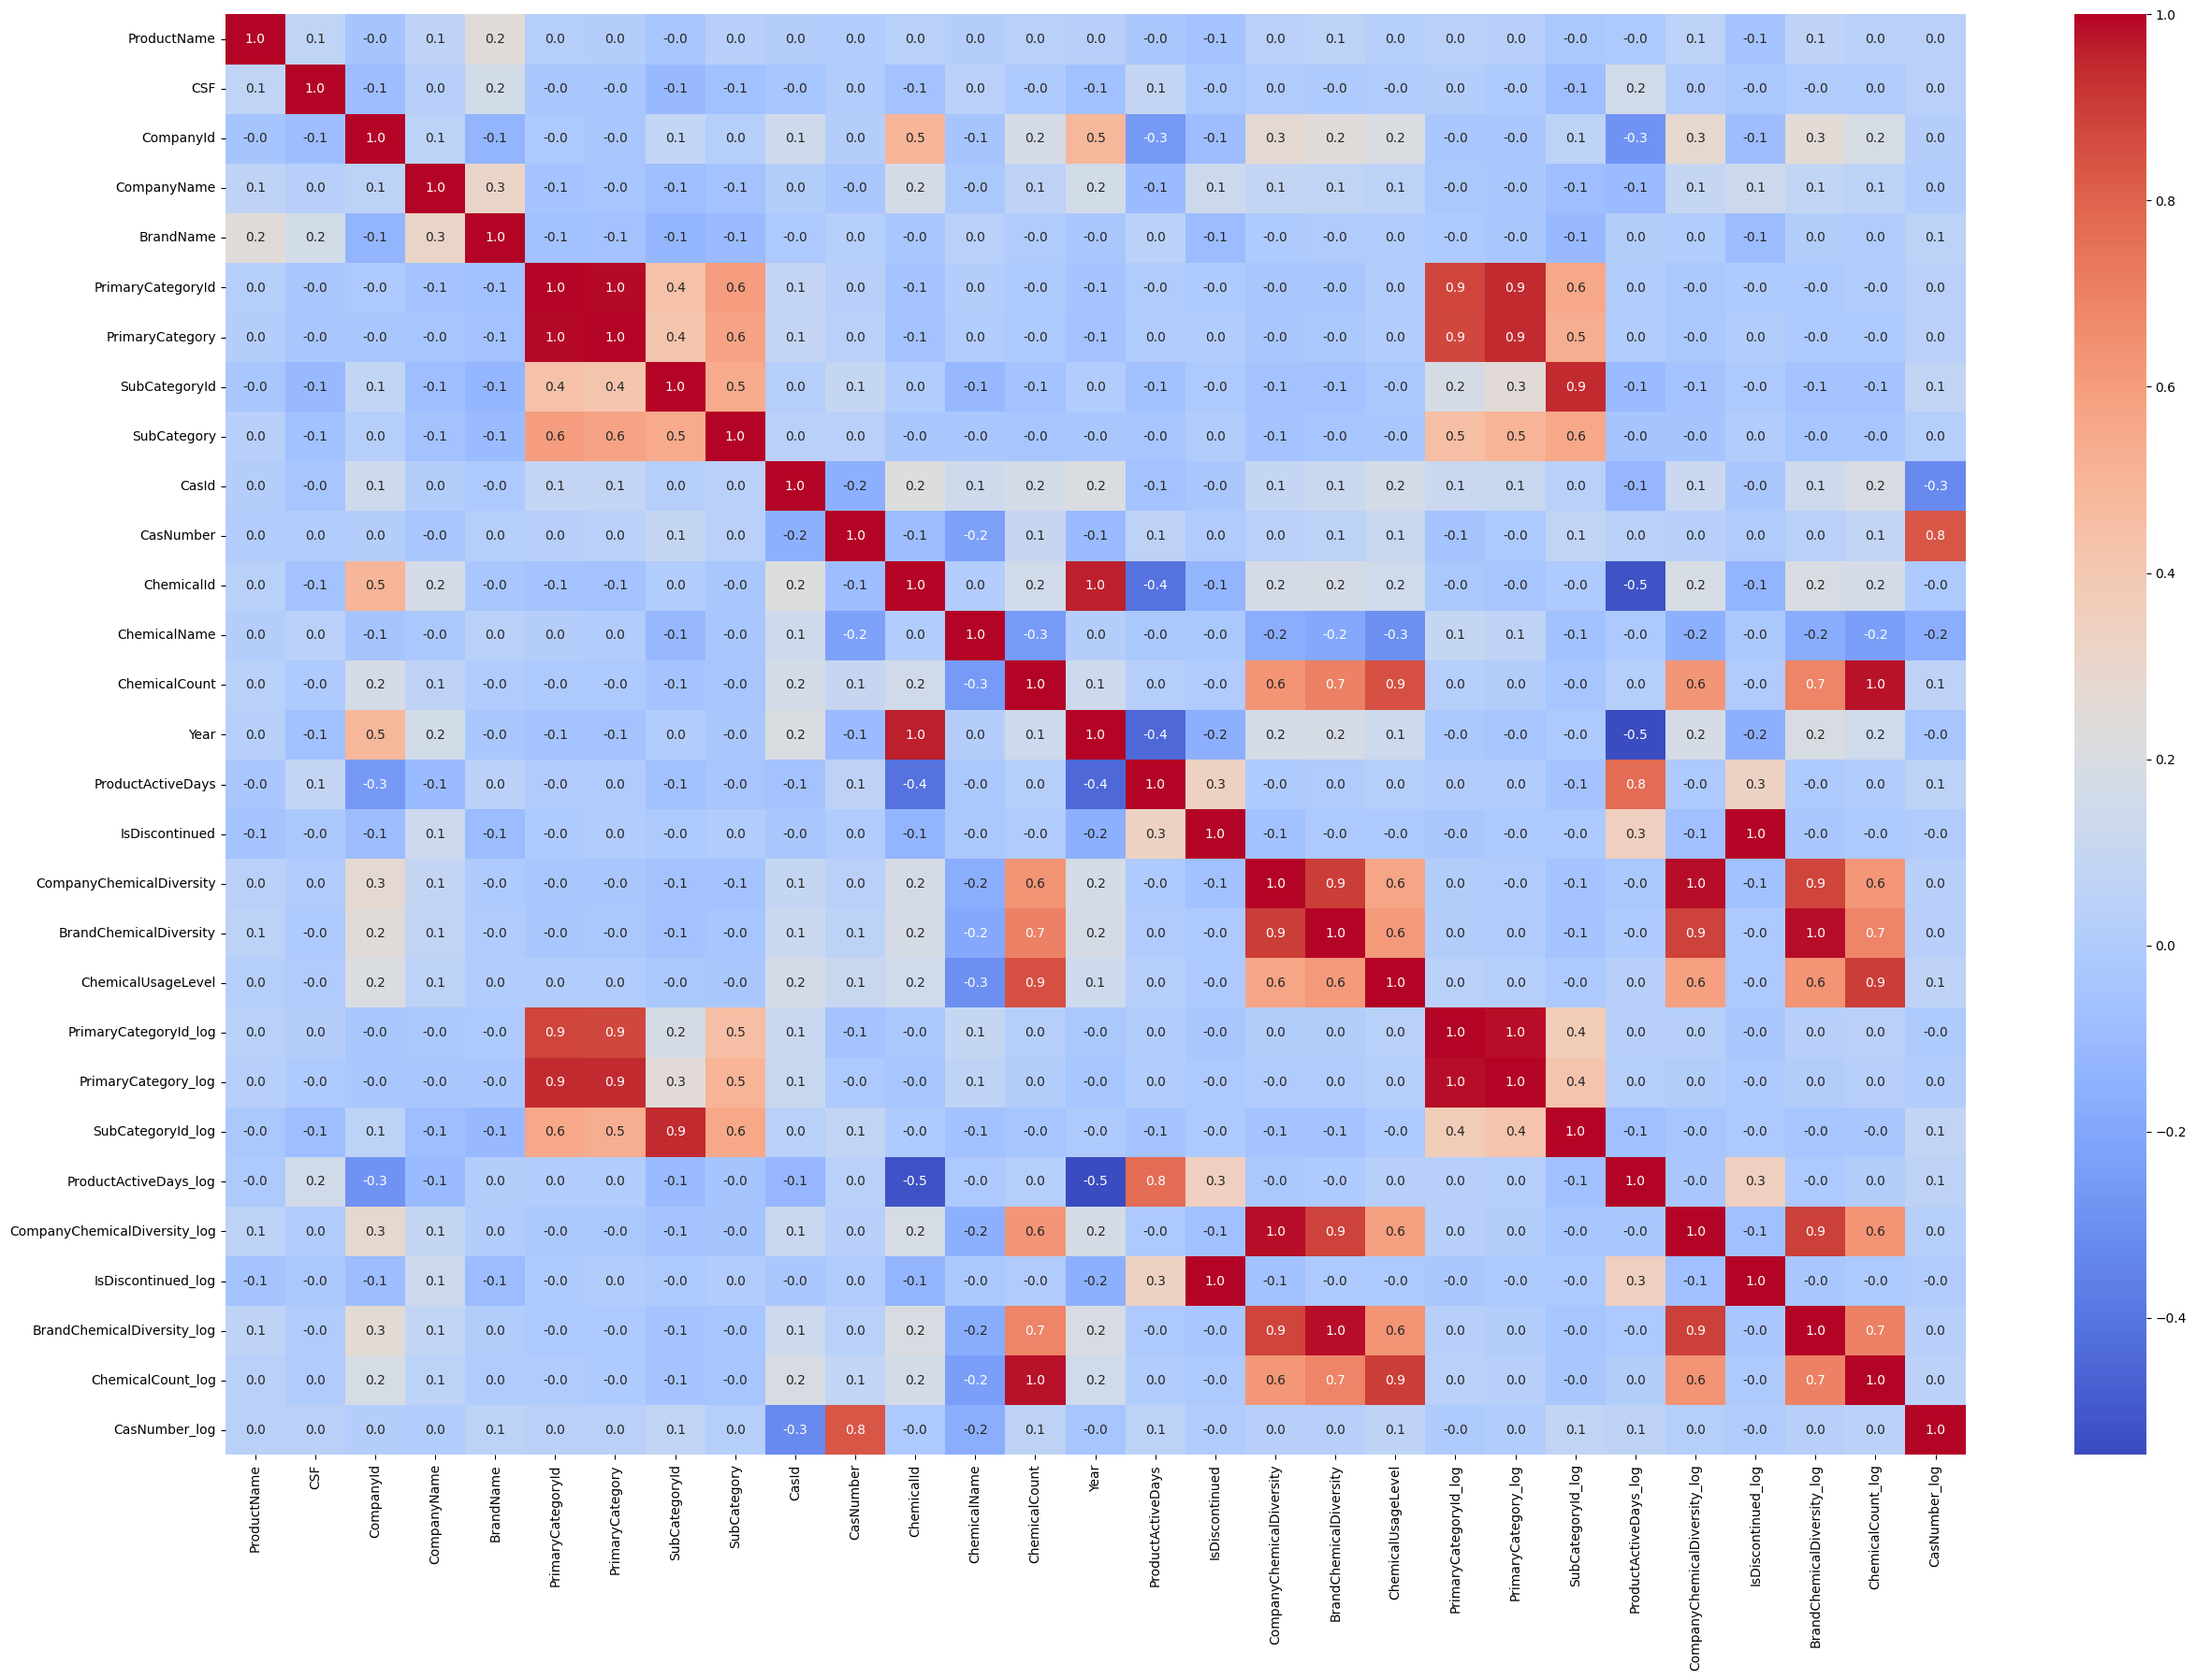

In [ ]:
plt.figure(figsize=(30,20))
#
cosmetics.corr(numeric_only=True)
sns.heatmap(cosmetics.corr(numeric_only=True),annot=True, cmap='coolwarm', fmt='0.01f',annot_kws=None)

In [ ]:
cosmetics.cov()

,ProductName,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,SubCategory,CasId,...,ChemicalUsageLevel,PrimaryCategoryId_log,PrimaryCategory_log,SubCategoryId_log,ProductActiveDays_log,CompanyChemicalDiversity_log,IsDiscontinued_log,BrandChemicalDiversity_log,ChemicalCount_log,CasNumber_log
ProductName,8.615924e+07,6.188436e+06,-1.750964e+05,107729.805195,1.690598e+06,4589.800113,395.870867,-12903.541003,5950.137868,21677.949671,...,87.736935,159.858779,89.631073,-99.489263,-465.992573,79.830432,-112.900754,106.303808,70.894967,111.509927
CSF,6.188436e+06,8.115837e+07,-3.334083e+05,49164.303432,1.073866e+06,-6266.012620,-722.336619,-36100.851124,-12679.917925,-59304.489912,...,-7.007524,69.082258,-14.378083,-331.435850,4639.179132,0.419818,-46.817692,-3.682511,1.524656,134.287155
CompanyId,-1.750964e+05,-3.334083e+05,1.677174e+05,3687.143826,-4.006764e+04,-155.719689,-24.125755,1196.061985,207.896700,8752.500752,...,35.652529,-6.526654,-4.676479,10.300009,-386.490453,18.343498,-8.300888,18.257409,17.618774,2.733111
CompanyName,1.077298e+05,4.916430e+04,3.687144e+03,30803.002141,4.008587e+04,-186.360535,-15.177916,-542.229738,-225.691912,306.068073,...,3.841906,-2.178027,-1.525447,-6.373756,-59.498293,2.725784,5.161641,2.582823,2.242841,0.210608
BrandName,1.690598e+06,1.073866e+06,-4.006764e+04,40085.870552,5.374628e+05,-979.239011,-89.419610,-3387.758414,-1608.770572,-1802.904520,...,1.168066,-5.858926,-6.636428,-35.273505,25.592738,0.727000,-15.951982,1.492008,0.056335,14.065615
PrimaryCategoryId,4.589800e+03,-6.266013e+03,-1.557197e+02,-186.360535,-9.792390e+02,419.198656,42.066203,319.146369,264.091484,280.660720,...,0.058031,8.432769,6.039152,5.025573,0.182160,-0.074548,-0.024499,-0.068679,-0.012356,0.287607
PrimaryCategory,3.958709e+02,-7.223366e+02,-2.412575e+01,-15.177916,-8.941961e+01,42.066203,4.275037,30.767630,25.736372,28.559099,...,0.003071,0.843078,0.611162,0.486424,0.052999,-0.007427,0.001235,-0.007330,-0.002226,0.028811
SubCategoryId,-1.290354e+04,-3.610085e+04,1.196062e+03,-542.229738,-3.387758e+03,319.146369,30.767630,1283.222664,420.558799,132.837595,...,-0.414540,3.061555,2.836184,14.982654,-11.824816,-0.303626,-0.109097,-0.338252,-0.445232,0.922270
SubCategory,5.950138e+03,-1.267992e+04,2.078967e+02,-225.691912,-1.608771e+03,264.091484,25.736372,420.558799,468.655299,110.446667,...,-0.282124,4.587684,3.395208,5.306386,-3.283949,-0.161549,0.013106,-0.158432,-0.214689,0.181649
CasId,2.167795e+04,-5.930449e+04,8.752501e+03,306.068073,-1.802905e+03,280.660720,28.559099,132.837595,110.446667,22264.848080,...,10.482747,7.919441,5.119956,2.357087,-59.120196,2.656581,-0.958574,3.582437,6.483732,-16.185784


In [ ]:
cosmetics.columns

Index(['ProductName', 'CSF', 'CompanyId', 'CompanyName', 'BrandName',
       'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId', 'SubCategory',
       'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName', 'ChemicalCount',
       'Year', 'ProductActiveDays', 'IsDiscontinued',
       'CompanyChemicalDiversity', 'BrandChemicalDiversity',
       'ChemicalUsageLevel', 'PrimaryCategoryId_log', 'PrimaryCategory_log',
       'SubCategoryId_log', 'ProductActiveDays_log',
       'CompanyChemicalDiversity_log', 'IsDiscontinued_log',
       'BrandChemicalDiversity_log', 'ChemicalCount_log', 'CasNumber_log'],
      dtype='object')

In [ ]:
cosmetics.columns

Index(['ProductName', 'CSF', 'CompanyId', 'CompanyName', 'BrandName',
       'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId', 'SubCategory',
       'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName', 'ChemicalCount',
       'Year', 'ProductActiveDays', 'IsDiscontinued',
       'CompanyChemicalDiversity', 'BrandChemicalDiversity',
       'ChemicalUsageLevel', 'PrimaryCategoryId_log', 'PrimaryCategory_log',
       'SubCategoryId_log', 'ProductActiveDays_log',
       'CompanyChemicalDiversity_log', 'IsDiscontinued_log',
       'BrandChemicalDiversity_log', 'ChemicalCount_log', 'CasNumber_log'],
      dtype='object')

In [ ]:
correlation_matrix=cosmetics.corr()
#set the correlation threshold
threshold=0.5
#find pairs of features with high correlation
highly_correlated_pairs=[]
for i in range(len(correlation_matrix.columns)):
  for j in range(i):
    #check if the absolute correlation exceeds the threshold
    if abs(correlation_matrix.iloc[i,j])>threshold:
      highly_correlated_pairs.append((correlation_matrix.columns[i],correlation_matrix.columns[j]))
      #print all pairs of highly correlated features
print(highly_correlated_pairs)

[('PrimaryCategory', 'PrimaryCategoryId'), ('SubCategory', 'PrimaryCategoryId'), ('SubCategory', 'PrimaryCategory'), ('SubCategory', 'SubCategoryId'), ('Year', 'ChemicalId'), ('CompanyChemicalDiversity', 'ChemicalCount'), ('BrandChemicalDiversity', 'ChemicalCount'), ('BrandChemicalDiversity', 'CompanyChemicalDiversity'), ('ChemicalUsageLevel', 'ChemicalCount'), ('ChemicalUsageLevel', 'CompanyChemicalDiversity'), ('ChemicalUsageLevel', 'BrandChemicalDiversity'), ('PrimaryCategoryId_log', 'PrimaryCategoryId'), ('PrimaryCategoryId_log', 'PrimaryCategory'), ('PrimaryCategory_log', 'PrimaryCategoryId'), ('PrimaryCategory_log', 'PrimaryCategory'), ('PrimaryCategory_log', 'SubCategory'), ('PrimaryCategory_log', 'PrimaryCategoryId_log'), ('SubCategoryId_log', 'PrimaryCategoryId'), ('SubCategoryId_log', 'PrimaryCategory'), ('SubCategoryId_log', 'SubCategoryId'), ('SubCategoryId_log', 'SubCategory'), ('ProductActiveDays_log', 'ChemicalId'), ('ProductActiveDays_log', 'Year'), ('ProductActiveDays_

In [ ]:
cosmetics.drop(['BrandChemicalDiversity_log', 'CompanyChemicalDiversity_log','IsDiscontinued_log','ProductActiveDays_log','SubCategoryId_log','PrimaryCategoryId_log','SubCategory', 'CasNumber_log','SubCategoryId','ChemicalCount_log','BrandChemicalDiversity_log','IsDiscontinued_log','PrimaryCategoryId_log' ,'ChemicalId', 'CasNumber','CSF','PrimaryCategoryId_log','PrimaryCategory_log',],axis=1,inplace=True)

In [ ]:
cosmetics.drop('CasId',axis=1,inplace=True)


In [ ]:
cosmetics.drop('PrimaryCategoryId',axis=1,inplace=True)

In [ ]:
#step:1 calculate the correlation of each feature with the target
corr_with_target=cosmetics.corr()['ChemicalCount'].sort_values(ascending=False)
#step2: set the threshold for low correlation (-0.05 to 0.05)
low_corr_features=corr_with_target[(corr_with_target > -0.05)&
                                   (corr_with_target < 0.05)]
#step 3: print the list of features with low correlation
print('features with correlation between -0.05 and 0.05:')
print(low_corr_features)

features with correlation between -0.05 and 0.05:
ProductName          0.032945
ProductActiveDays    0.020950
BrandName           -0.000682
IsDiscontinued      -0.002323
PrimaryCategory     -0.012683
Name: ChemicalCount, dtype: float64


In [ ]:
cosmetics.drop('IsDiscontinued',axis=1,inplace=True)

In [ ]:
#step 1: Calculate the correlation of each features with target
corr_with_target=cosmetics.corr()['ChemicalUsageLevel'].sort_values(ascending=False)
corr_with_target
#step2: lset the threshold for low correlation (-0.05 to 0.05)
low_corr_features=corr_with_target[(corr_with_target > -0.05)&
                                   (corr_with_target < 0.05)]
#step 3: print the list of features with low correlation
print('features with correlation between -0.05 and 0.05:')
print(low_corr_features)

features with correlation between -0.05 and 0.05:
ProductActiveDays    0.024785
ProductName          0.022421
BrandName            0.003779
PrimaryCategory      0.003524
Name: ChemicalUsageLevel, dtype: float64


In [ ]:
cosmetics.drop('PrimaryCategory',axis=1,inplace=True)

In [ ]:
cosmetics.drop('Year',axis=1,inplace=True)

# PCA 

### PCA reduces the number of features(dimensions) in a dataset.
> principal components: these are the new features created by PCA. each principal component is a linear combination of the original features, and they are ranked based on the amount of variance they explain in the data.

In [ ]:
from sklearn.decomposition import PCA
#apply PCA
pca=PCA(n_components=5) # you can change the number of components to retain
cosmetics_pca=pca.fit_transform(cosmetics)
#create a dataframe with the PCA results
cosmetics_pca_df=pd.DataFrame(cosmetics_pca,columns=[f'PC{i+1}' for i in range(cosmetics_pca.shape[1])])
#step 5: combine the PCA components with the original DataFrame if needed
cosmetics_pca_final_df=pd.concat([cosmetics.reset_index(drop=True),cosmetics_pca_df],axis=1)
# now cosmetics_pca_final_df contains the original data along with the PCA components
cosmetics_pca_df.head()

,PC1,PC2,PC3,PC4,PC5
0,13391.012113,784.376988,-1783.296843,-379.683150,231.494062
1,-4460.537183,-562.637478,-242.607968,-235.872372,-16.988279
2,-4460.537143,-562.637765,-242.606865,-235.875236,-16.992836
3,5254.708736,773.666842,-1616.339725,-389.359661,227.982139
4,-16255.962074,801.675859,-1186.049163,-405.685872,219.910929


# Scaling

### Standardization

In [ ]:
# Create a copy df for scaling
cosmetics_scaled_df=cosmetics.copy()
# Select numeric columns,excluding 'ChemicalUsageLevel'
numeric_columns = cosmetics.drop(columns=['ChemicalUsageLevel']).select_dtypes(include=['number']).columns
# Initialize the standardscalar
scaler=StandardScaler()
#apply the scalar only to the numeric columns
cosmetics_scaled_df[numeric_columns]=scaler.fit_transform(cosmetics[numeric_columns])
cosmetics_scaled_df.head()

,ProductName,CompanyId,CompanyName,BrandName,ChemicalName,ChemicalCount,ProductActiveDays,CompanyChemicalDiversity,BrandChemicalDiversity,ChemicalUsageLevel
0,1.446082,-1.090616,0.421784,-1.889979,0.326437,-0.453098,1.211057,-0.691855,-0.627060,0
1,-0.479871,-0.275050,-0.261950,-0.606416,-2.547512,1.118202,-0.629821,-0.771439,0.845804,1
2,-0.479871,-0.275050,-0.261950,-0.606416,-2.497961,1.118202,-0.629821,-0.771439,0.845804,1
3,0.569346,-1.090616,0.421784,-1.889979,0.326437,-0.453098,1.184639,-0.691855,-0.627060,0
4,-1.748541,-1.090616,0.421784,-1.889979,0.326437,-0.453098,1.184639,-0.691855,-0.627060,0


In [ ]:
cosmetics.shape

(114635, 10)

## Handling Outliers

### Boxplot

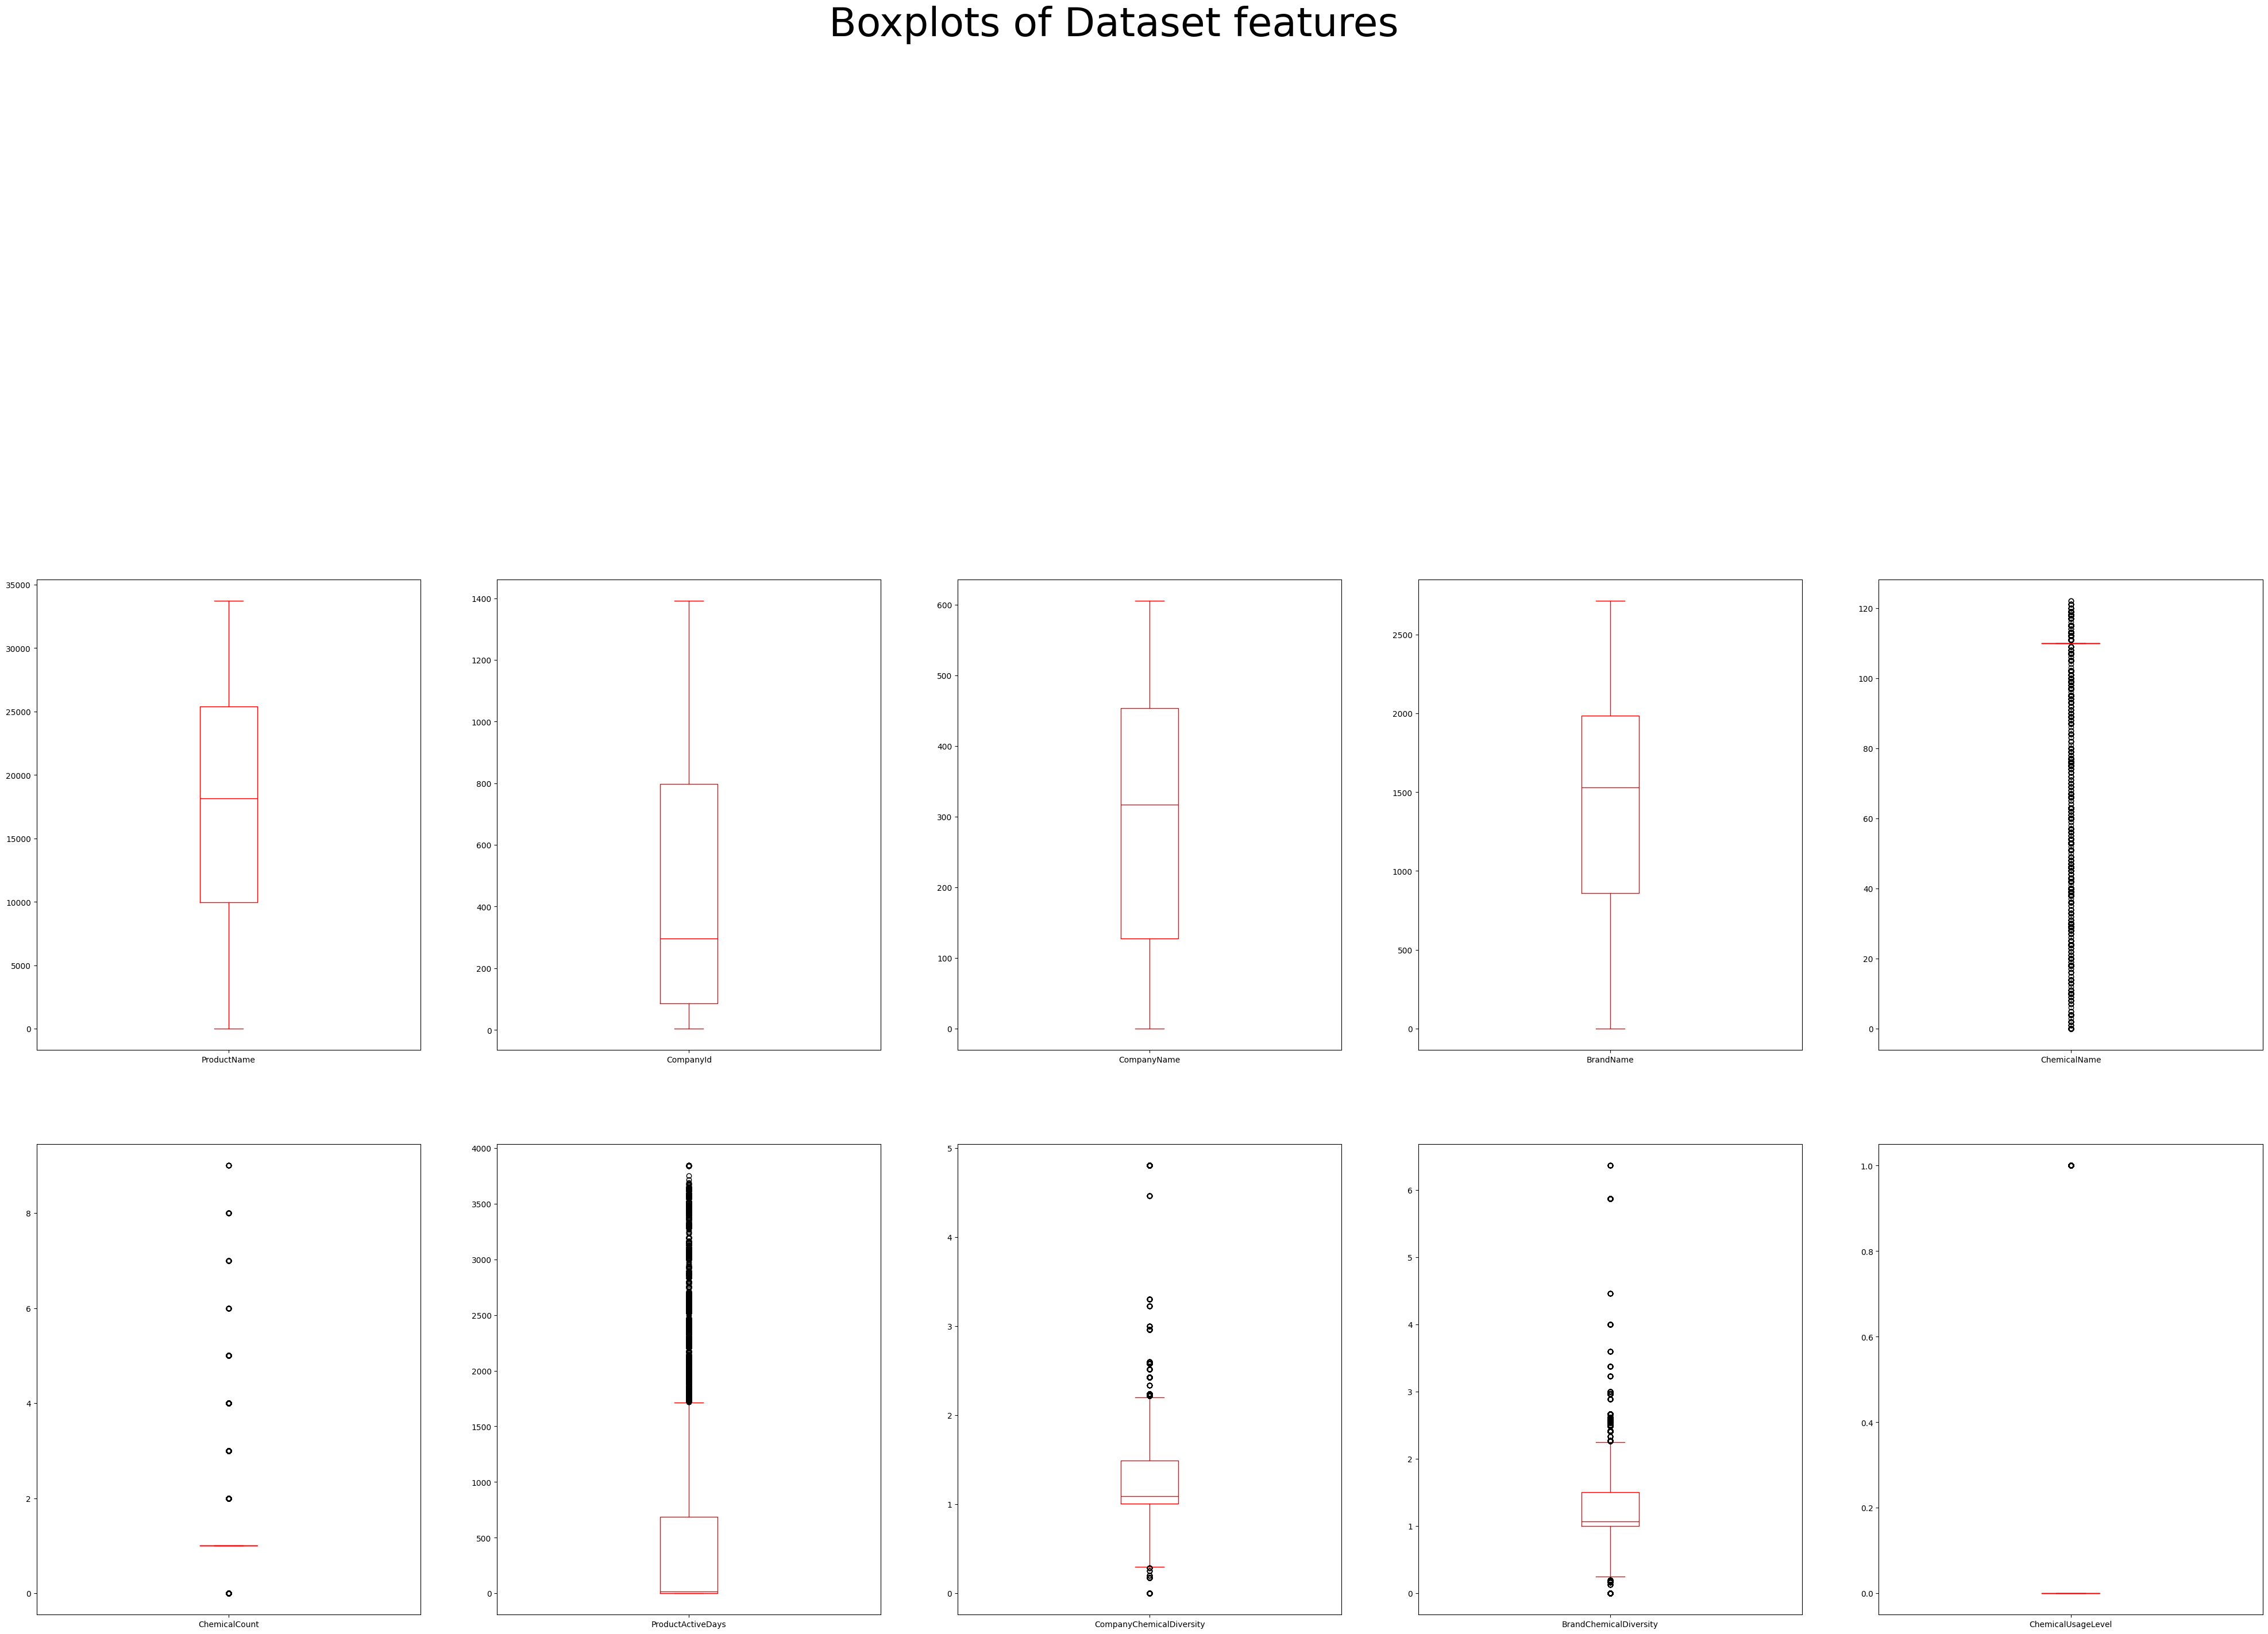

In [ ]:
cosmetics.plot(kind='box',subplots=True, layout=(8,5),figsize=(50,100),color='red')
plt.suptitle('Boxplots of Dataset features',fontsize=50)
plt.show()

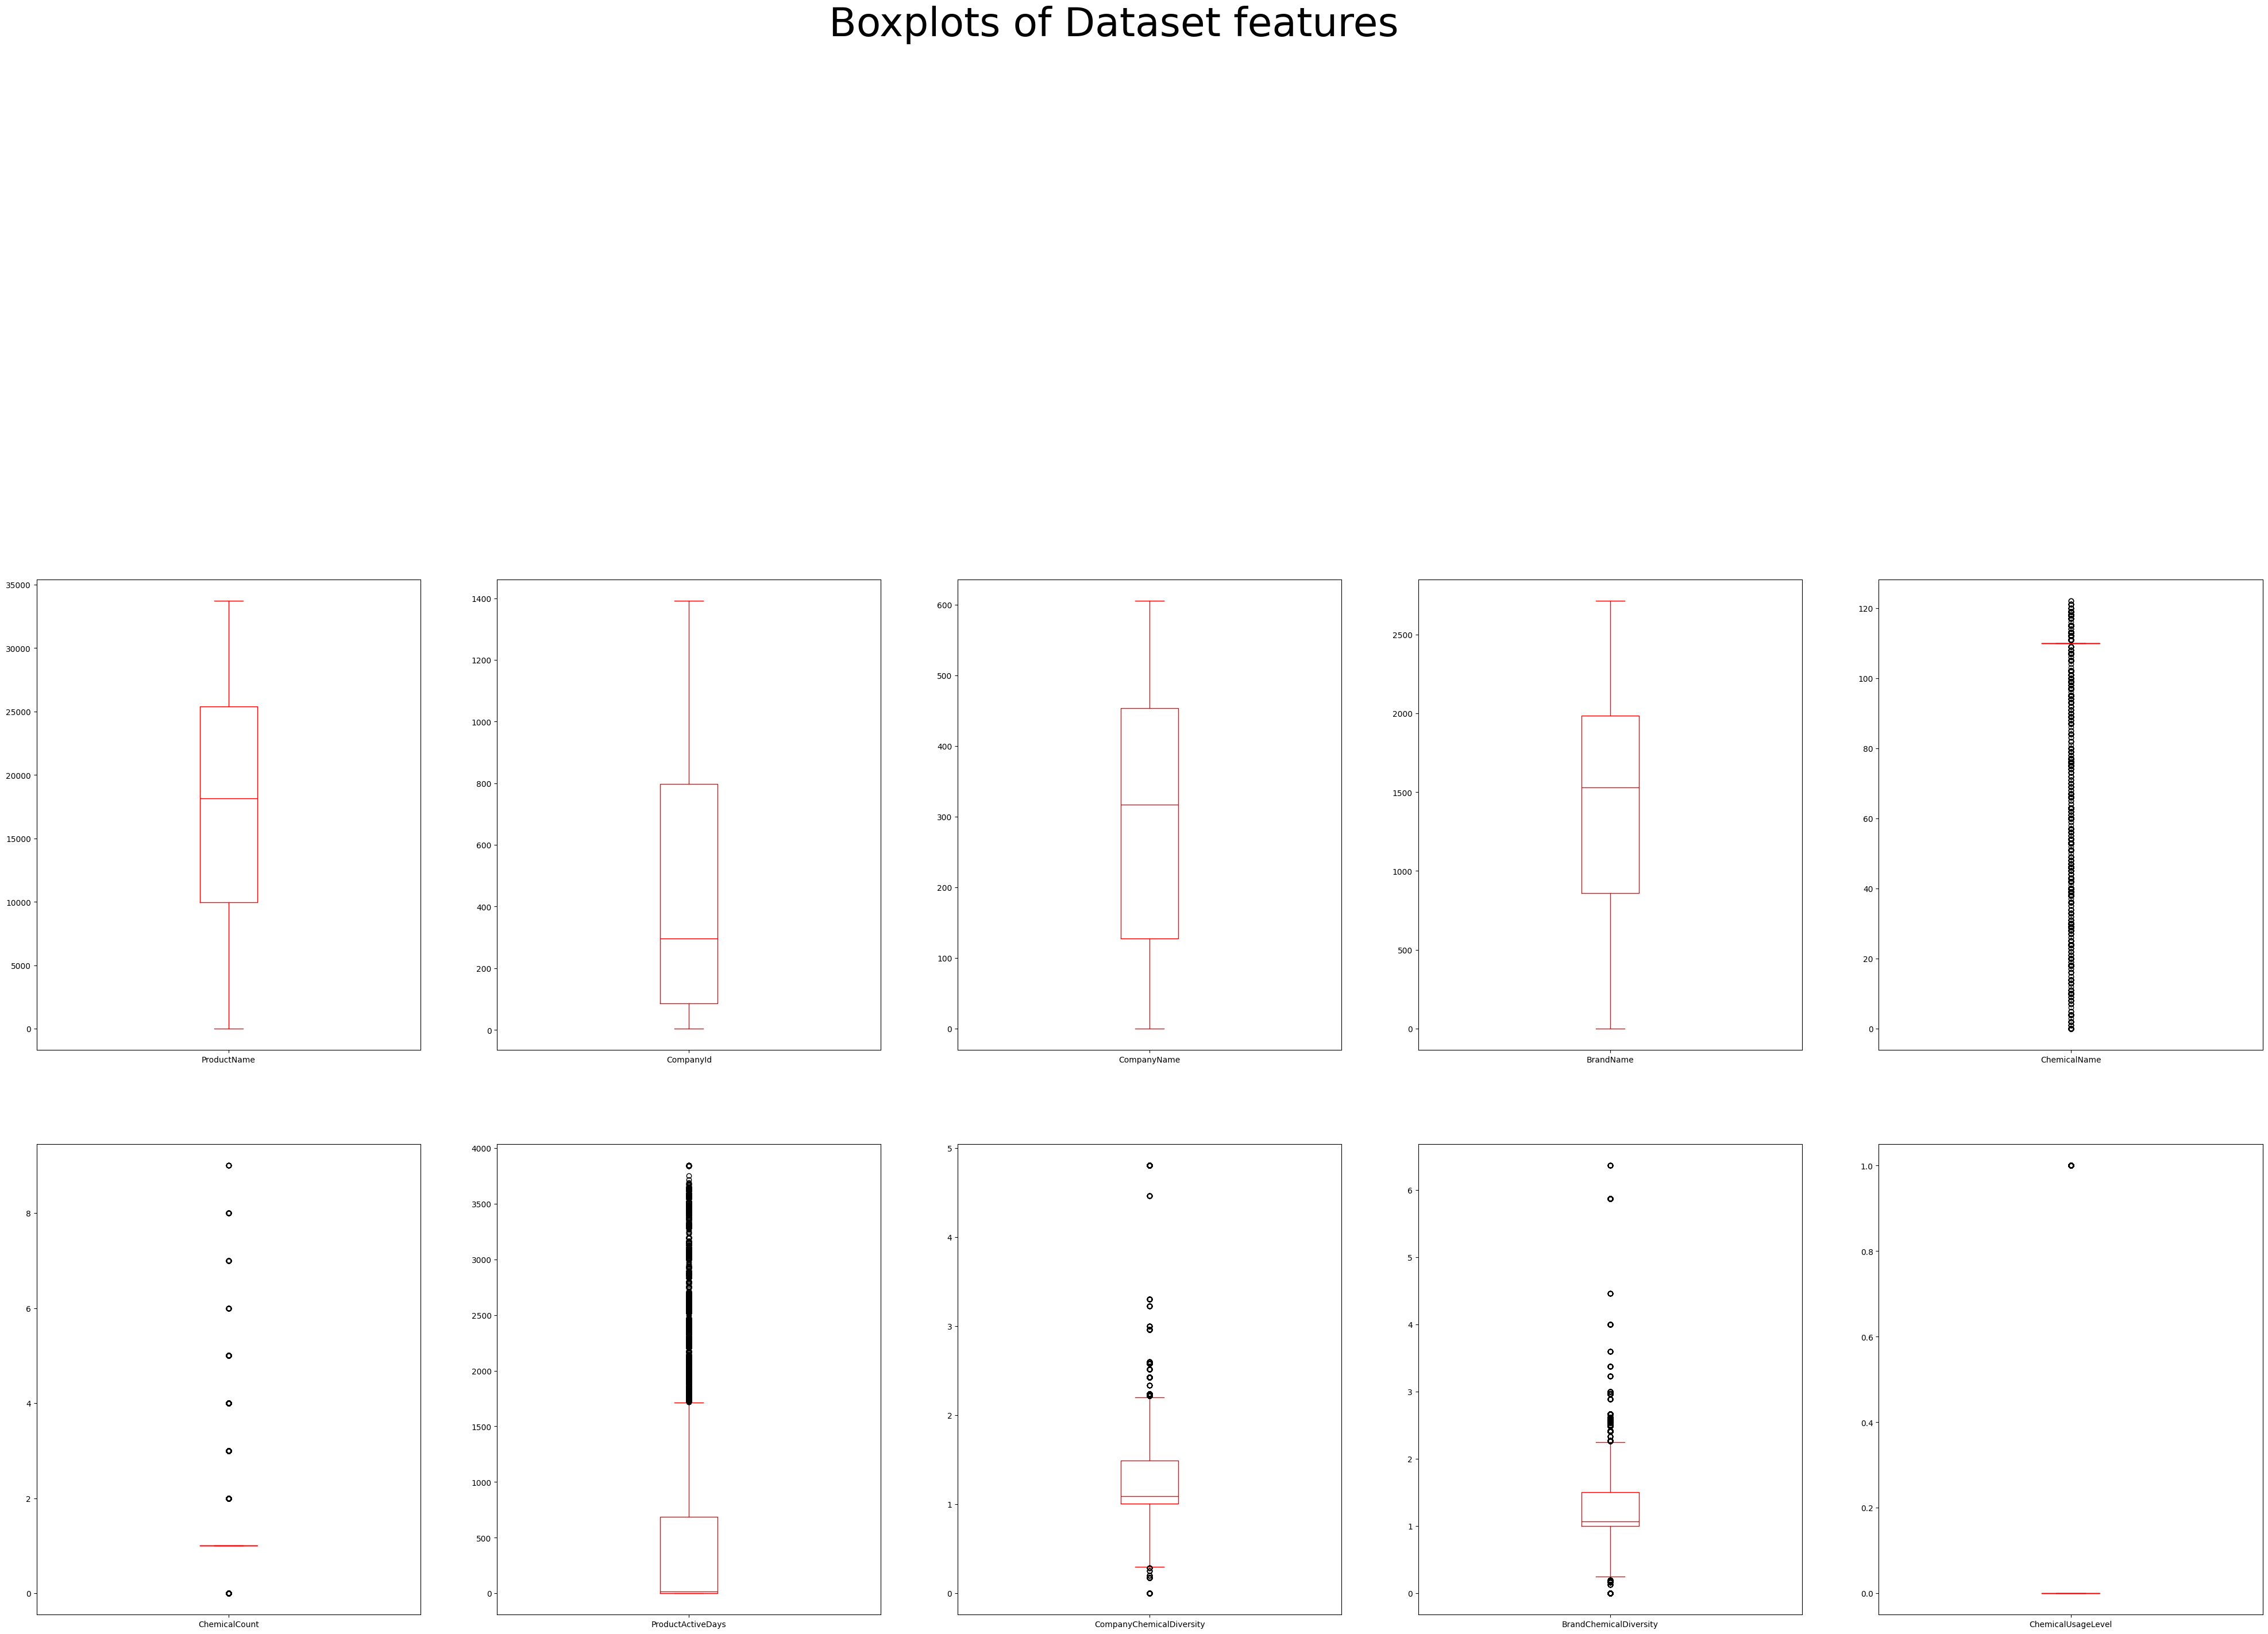

In [ ]:
cosmetics.plot(kind='box',subplots=True, layout=(8,5),figsize=(50,100),color='red')
plt.suptitle('Boxplots of Dataset features',fontsize=50)
plt.show()

In [ ]:
# create a copy of the original data for comparison
cosmetics_df_copy=cosmetics.copy()
def remove_outliers_iqr(dataf,exclude_columns):
  #loop through numeric columns
  for column in dataf.select_dtypes(include=['number']):
    if column in exclude_columns:
      continue #skip excluded columns
    Q1=dataf[column].quantile(0.25)
    Q3=dataf[column].quantile(0.75)
    IQR=Q3-Q1
    # define outlier bounds
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    # filter out the outliers
    dataf=dataf[(dataf[column]>= lower_bound) & (dataf[column]<=upper_bound)]
  return dataf
     #define the columns to exclude
exclude_columns=['ChemicalCount','ChemicalUsageLevel']
#remove outliers
cosmetics=remove_outliers_iqr(cosmetics,exclude_columns)
#print shapes of data before  and after removing outliers
print('Shape of data before removing outliers:',cosmetics_df_copy.shape)
print('Shape of data after removing outliers:',cosmetics.shape)
print('Number of outliers removed:',cosmetics_df_copy.shape[0]-cosmetics.shape[0])

Shape of data before removing outliers: (114635, 10)
Shape of data after removing outliers: (77066, 10)
Number of outliers removed: 37569


## Model Training and Evaluation
### Classification Modeling
> Binary ChemicalUsageLevel Classification : To determine the binary outcome of ChemicalUsageLevel,indicating whether ChemicalUsageLevel is likely used high or low in a product.

In [ ]:
x=cosmetics.drop(['ChemicalUsageLevel','ChemicalCount'],axis=1)
y=cosmetics[['ChemicalUsageLevel']]

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
print('Shape of training features:',x_train.shape)
print('Shape of testing features:',x_test.shape)
print('Shape of training target:',y_train.shape)
print('Shape of training target:',y_test.shape)

Shape of training features: (61652, 8)
Shape of testing features: (15414, 8)
Shape of training target: (61652, 1)
Shape of training target: (15414, 1)


In [ ]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
# Accuracy
acc=accuracy_score(y_test,y_pred)
print('Accuracy:',acc)
# confusion Matrix
print("\nConfusion matrix:\n",confusion_matrix(y_test,y_pred))
#Detailed classification report
print("\n Classification report:\n",classification_report(y_test,y_pred))

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.9068379395354872

Confusion matrix:
 [[13965    11]
 [ 1425    13]]

 Classification report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95     13976
           1       0.54      0.01      0.02      1438

    accuracy                           0.91     15414
   macro avg       0.72      0.50      0.48     15414
weighted avg       0.87      0.91      0.86     15414



c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
clas_models={'lr':LogisticRegression(max_iter=500),
             'rfc':RandomForestClassifier(max_depth=10),
             'dtc':DecisionTreeClassifier(),
             #'knn':KNeighborsClassifier(n_neighbors=11),
             #'svm':SVC(kernel='linear'),
             'gbc':GradientBoostingClassifier(random_state=0,learning_rate=0.45),
             'etc':ExtraTreesClassifier(),
             'nb':GaussianNB()}

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
#Dictionary to store results
results={'Model':[],'Accuracy':[],'Precision':[],'Recall':[],'F1_Score':[]}
# Evaluate each model
for model_name,model in clas_models.items():
  #train the model
  model.fit(x_train,y_train)
  model_pred=model.predict(x_test)
  #Calculate metrics
  accuracy=accuracy_score(y_test,model_pred)
  precision=precision_score(y_test,model_pred)
  recall=recall_score(y_test,model_pred)
  f1=f1_score(y_test,model_pred)
  #Store results in the dictionary
  results['Model'].append(model)
  results['Accuracy'].append(accuracy)
  results['Precision'].append(precision)
  results['Recall'].append(recall)
  results['F1_Score'].append(f1)
#Convert results to a DataFrame
results_df=pd.DataFrame(results)
# Display the results in a table
results_df

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWa

,Model,Accuracy,Precision,Recall,F1_Score
0,LogisticRegression(max_iter=500),0.912547,0.571885,0.248957,0.346899
1,"(DecisionTreeClassifier(max_depth=10, max_feat...",0.956663,0.940503,0.571627,0.711073
2,DecisionTreeClassifier(),0.969768,0.848637,0.822670,0.835452
3,([DecisionTreeRegressor(criterion='friedman_ms...,0.957766,0.897877,0.617524,0.731768
4,"(ExtraTreeClassifier(random_state=1900338868),...",0.969703,0.856723,0.810848,0.833155
5,GaussianNB(),0.904438,0.427386,0.071627,0.122692


### Classification on Scaled Data

In [ ]:
x2s=cosmetics_scaled_df.drop(['ChemicalUsageLevel','ChemicalCount'],axis=1)
y2s=cosmetics_scaled_df[['ChemicalUsageLevel']]

x2s_train,x2s_test,y2s_train,y2s_test=train_test_split(x2s,y2s,random_state=42,test_size=0.2)
#Dictionary to store results
results={'Model':[],'Accuracy':[],'Precision':[],'Recall':[],'F1_Score':[]}
# Evaluate each model
for model_name,model in clas_models.items():
  #train the model
  model.fit(x2s_train,y2s_train)
  model_pred2s=model.predict(x2s_test)
  #Calculate metrics
  accuracy2=accuracy_score(y2s_test,model_pred2s)
  precision2=precision_score(y2s_test,model_pred2s)
  recall2=recall_score(y2s_test,model_pred2s)
  f12=f1_score(y2s_test,model_pred2s)
  #Store results in the dictionary
  results['Model'].append(model)
  results['Accuracy'].append(accuracy2)
  results['Precision'].append(precision2)
  results['Recall'].append(recall2)
  results['F1_Score'].append(f12)
#Convert results to a DataFrame
results_df2=pd.DataFrame(results)
# sort by accuracy
results_df2=results_df2.sort_values(by='Accuracy',ascending=False)
# Display the sorted frame with bg gradient
results_df2.style.background_gradient('Blues')


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWa

,Model,Accuracy,Precision,Recall,F1_Score
4,ExtraTreesClassifier(),0.962926,0.927891,0.908814,0.918254
2,DecisionTreeClassifier(),0.961705,0.923032,0.908624,0.915771
3,"GradientBoostingClassifier(learning_rate=0.45, random_state=0)",0.933048,0.880164,0.819341,0.848664
1,RandomForestClassifier(max_depth=10),0.924630,0.882736,0.773844,0.824711
0,LogisticRegression(max_iter=500),0.867667,0.824700,0.536455,0.650058
5,GaussianNB(),0.843591,0.664236,0.641729,0.652789


## Regression Model

In [ ]:
x1=cosmetics.drop(['ChemicalUsageLevel','ChemicalCount'],axis=1)
y1=cosmetics[['ChemicalCount']]
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,random_state=42,test_size=0.2)
print('Shape of training features:',x1_train.shape)
print('Shape of testing features:',x1_test.shape)
print('Shape of training target:',y1_train.shape)
print('Shape of training target:',y1_test.shape)


Shape of training features: (61652, 8)
Shape of testing features: (15414, 8)
Shape of training target: (61652, 1)
Shape of training target: (15414, 1)


In [ ]:
models={"Linear_regression":LinearRegression(),
        "RandomForest_Regressor":RandomForestRegressor(),
        "GradientBoosting_Regressor":GradientBoostingRegressor(),
        "DecisionTree_Regressor":DecisionTreeRegressor(),
        #"SVM":SVR(),
        #"AdaBoostRegressor":AdaBoostRegressor(),
        "ExtraTreesRegressor":ExtraTreesRegressor(),
        #"BaggingRegressor":BaggingRegressor(),
        "LGBMRegressor":LGBMRegressor(),
        "XGBRegressor":XGBRegressor()
        }

In [ ]:
#Dictionary to store results
results={'Model':[],'MSE':[],'MAE':[],'R2':[]}
#loop through the models,train them,and calculate the metrics
for model_name,model in models.items():
  #train the model
  model.fit(x1_train,y1_train)
  #make predictions
  y1_pred=model.predict(x1_test)
  #calculate metrics
  mse=mean_squared_error(y1_test,y1_pred)
  mae=mean_absolute_error(y1_test,y1_pred)
  r2=r2_score(y1_test,y1_pred)
    #Store results in the dictionary
  results['Model'].append(model_name)
  results['MSE'].append(mse)
  results['MAE'].append(mae)
  results['R2'].append(r2)
 #Convert results to a DataFrame
results_df2=pd.DataFrame(results)
# Display the results in a table
results_df2

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1507
[LightGBM] [Info] Number of data points in the train set: 61652, number of used features: 7
[LightGBM] [Info] Start training from score 1.093087


,Model,MSE,MAE,R2
0,Linear_regression,0.078913,0.141835,0.219996
1,RandomForest_Regressor,0.026208,0.039168,0.740946
2,GradientBoosting_Regressor,0.057301,0.112121,0.433610
3,DecisionTree_Regressor,0.033145,0.036869,0.672385
4,ExtraTreesRegressor,0.027500,0.036283,0.728182
5,LGBMRegressor,0.039530,0.082319,0.609268
6,XGBRegressor,0.033204,0.069137,0.671800


In [ ]:
x1s=cosmetics_scaled_df.drop(['ChemicalUsageLevel','ChemicalCount'],axis=1)
y1s=cosmetics_scaled_df[['ChemicalCount']]
x1s_train,x1s_test,y1s_train,y1s_test=train_test_split(x1s,y1s,random_state=42,test_size=0.2)
#Dictionary to store results
results={'Model':[],'MSE':[],'MAE':[],'R2':[]}
#loop through the models,train them,and calculate the metrics
for model_name,model in models.items():
  #train the model
  model.fit(x1s_train,y1s_train)
  #make predictions
  y1s_pred=model.predict(x1s_test)
  #calculate metrics
  mse1=mean_squared_error(y1s_test,y1s_pred)
  mae1=mean_absolute_error(y1s_test,y1s_pred)
  r21=r2_score(y1s_test,y1s_pred)
    #Store results in the dictionary
  results['Model'].append(model_name)
  results['MSE'].append(mse1)
  results['MAE'].append(mae1)
  results['R2'].append(r21)
 #Convert results to a DataFrame
results_df2=pd.DataFrame(results)
results_df2

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1732
[LightGBM] [Info] Number of data points in the train set: 91708, number of used features: 8
[LightGBM] [Info] Start training from score 0.001066


,Model,MSE,MAE,R2
0,Linear_regression,0.484334,0.401260,0.511260
1,RandomForest_Regressor,0.116329,0.099954,0.882613
2,GradientBoosting_Regressor,0.347861,0.326404,0.648975
3,DecisionTree_Regressor,0.147280,0.090500,0.851380
4,ExtraTreesRegressor,0.126117,0.093292,0.872736
5,LGBMRegressor,0.246419,0.256406,0.751340
6,XGBRegressor,0.202784,0.220516,0.795371


In [ ]:
cosmetics

,ProductName,CompanyId,CompanyName,BrandName,ChemicalName,ChemicalCount,ProductActiveDays,CompanyChemicalDiversity,BrandChemicalDiversity,ChemicalUsageLevel
0,30981,4,372,82,110,1,1533,1.007874,1.007890,0
3,22843,4,372,82,110,1,1511,1.007874,1.007890,0
4,1328,4,372,82,110,1,1511,1.007874,1.007890,0
5,15171,4,372,82,110,1,1511,1.007874,1.007890,0
6,920,11,384,1714,110,1,535,1.000000,1.071429,0
...,...,...,...,...,...,...,...,...,...,...
114630,13606,1259,579,2578,110,1,0,1.011834,1.000000,0
114631,13606,1259,579,2578,110,1,0,1.011834,1.000000,0
114632,13606,1259,579,2578,110,1,0,1.011834,1.000000,0
114633,13606,1259,579,2578,110,1,0,1.011834,1.000000,0


### Final Report
> Based on the analysis of the cosmetics Chemicalcount dataset for predicting the `Chemicalcount`, the `RandomForest_Regressor` model  demonstrated the best performance among the tested models.

> Based on the evaluation of the classification models for predicting `ChemicalUsageLevel` ,the `LogisticRegression()` with a learning rate of 0.45
and random state set to 0 emerged as the best-performing model .it achieved the best accuracy and consistently strong results across precision,recall and F1-score, making it the most reliable model for classifying whether ChemicalUsageLevel is likely used high or low in a product.

In [ ]:
cosmetics.shape

(77066, 10)